#### This document is for analysis on FACT-E emotional well being (EWB).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import re

# Preliminary

In [2]:
# Read the CSV file - linked file 
file_path = "Merged_TSQIC_REDCap_ACCESS.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,dob,qol_date,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,...,ge1,ge2,ge3,ge4,ge5,ge6,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,1949-08-04,NaT,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10094,1766,NaT,baseline_arm_1,NaT,NaT,62.845917,NaN,1b,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10095,1766,2025-02-26,surgery_arm_1,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10096,1767,NaT,baseline_arm_1,1971-12-18,NaT,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
10097,1767,NaT,baseline_arm_1,NaT,2025-03-03,NaN,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN,NaT


In [3]:
df_extracted = df.copy()

# FACT E EWB calculation

In [4]:
# Step 1: Find eligible IDs (modified: requires only baseline_arm_1)
def find_eligible_ids(df):
    id_events = df.groupby('id')['redcap_event_name'].apply(set)
    eligible_ids = []
    for id_val, events in id_events.items():
        has_baseline = "baseline_arm_1" in events
        if has_baseline:  # Only need baseline now
            eligible_ids.append(id_val)
    return eligible_ids

# Step 2: Filter dataset (unchanged)
def filter_eligible_data(df, eligible_ids):
    return df[df['id'].isin(eligible_ids)].copy()

# Step 3: Calculate EWB subscale score only (unchanged)
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    return df

# Step 4: Analyze baseline scores only (replaces the improvement analysis)
def analyze_baseline_scores(df):
    results = []
    unique_ids = df['id'].unique()
    
    score_types = ['ewb_subscale_score']  # Only EWB score
    
    for id_val in unique_ids:
        id_data = df[df['id'] == id_val]
        
        # Filter only baseline data
        baseline_data = id_data[id_data['redcap_event_name'] == 'baseline_arm_1']
        
        # Skip if baseline data is missing
        if baseline_data.empty:
            continue
        
        # Get the baseline scores
        baseline_scores = baseline_data[score_types].mean().to_dict()
        
        # Skip if EWB score is not calculatable (NaN)
        if pd.isna(baseline_scores['ewb_subscale_score']):
            print(f"Skipping ID {id_val}: EWB score not calculatable (Baseline: {baseline_scores['ewb_subscale_score']})")
            continue
        
        # Print scores
        print(f"ID {id_val} Baseline score: [{', '.join([f'{k}: {v:.1f}' for k, v in baseline_scores.items()])}]")
        
        # Store results
        result = {'id': id_val, 'baseline_type': 'baseline_arm_1'}
        for score_type in score_types:
            result.update({
                f'{score_type}_baseline': baseline_scores[score_type]
            })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Main function (modified to focus on baseline only)
def analyze_patient_outcomes(df):
    required_cols = ['id', 'redcap_event_name'] + [f"ge{i}" for i in range(1, 7)]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    eligible_ids = find_eligible_ids(df)
    print(f"Found {len(eligible_ids)} eligible IDs with baseline data")
    
    filtered_df = filter_eligible_data(df, eligible_ids)
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    filtered_df = calculate_all_scores(filtered_df)
    
    score_cols = [col for col in filtered_df.columns if col.endswith('_score')]
    print(f"Created score columns: {score_cols}")
    
    # Extract only baseline data for analysis
    baseline_df = filtered_df[filtered_df['redcap_event_name'] == 'baseline_arm_1'].copy()
    
    score_types = ['ewb_subscale_score']
    for score_type in score_types:
        non_nan_count = baseline_df[score_type].notna().sum()
        print(f"Non-NaN {score_type} at baseline: {non_nan_count} out of {len(baseline_df)}")
    
    results_df = analyze_baseline_scores(filtered_df)
    
    if not results_df.empty:
        print(f"\nAnalysis complete for {len(results_df)} patients with valid baseline scores:")
        
        # Summary statistics for baseline scores
        for score_type in score_types:
            mean_score = results_df[f'{score_type}_baseline'].mean()
            median_score = results_df[f'{score_type}_baseline'].median()
            std_score = results_df[f'{score_type}_baseline'].std()
            min_score = results_df[f'{score_type}_baseline'].min()
            max_score = results_df[f'{score_type}_baseline'].max()
            
            print(f"\n{score_type} Summary Statistics:")
            print(f"  Mean: {mean_score:.2f}")
            print(f"  Median: {median_score:.2f}")
            print(f"  Standard Deviation: {std_score:.2f}")
            print(f"  Range: {min_score:.2f} to {max_score:.2f}")
    
    return baseline_df, results_df

# Example usage
filtered_df, results_df = analyze_patient_outcomes(df)

Found 1752 eligible IDs with baseline data
Filtered dataframe shape: (10099, 27)
Created score columns: ['ge1_score', 'ge2_score', 'ge3_score', 'ge4_score', 'ge5_score', 'ge6_score', 'ewb_subscale_score']
Non-NaN ewb_subscale_score at baseline: 1046 out of 4428
Skipping ID 1: EWB score not calculatable (Baseline: nan)
ID 2 Baseline score: [ewb_subscale_score: 14.0]
ID 3 Baseline score: [ewb_subscale_score: 14.0]
ID 4 Baseline score: [ewb_subscale_score: 23.0]
Skipping ID 5: EWB score not calculatable (Baseline: nan)
Skipping ID 6: EWB score not calculatable (Baseline: nan)
ID 7 Baseline score: [ewb_subscale_score: 5.0]
ID 8 Baseline score: [ewb_subscale_score: 18.0]
ID 9 Baseline score: [ewb_subscale_score: 20.0]
Skipping ID 10: EWB score not calculatable (Baseline: nan)
Skipping ID 11: EWB score not calculatable (Baseline: nan)
ID 12 Baseline score: [ewb_subscale_score: 14.0]
ID 13 Baseline score: [ewb_subscale_score: 23.0]
Skipping ID 14: EWB score not calculatable (Baseline: nan)
Sk

In [5]:
results_df

,id,baseline_type,ewb_subscale_score_baseline
0,2,baseline_arm_1,14.0
1,3,baseline_arm_1,14.0
2,4,baseline_arm_1,23.0
3,7,baseline_arm_1,5.0
4,8,baseline_arm_1,18.0
...,...,...,...
909,1762,baseline_arm_1,21.0
910,1763,baseline_arm_1,14.0
911,1765,baseline_arm_1,15.0
912,1766,baseline_arm_1,7.0


In [6]:
# Set 'id' column as the index
results_df = results_df.set_index("id")

# Rename the index and columns to match the second image
results_df.index.name = "id"
results_df.columns.name = "Timepoint"

score_comparison=results_df.copy()
score_comparison

Timepoint,baseline_type,ewb_subscale_score_baseline
id,,
2,baseline_arm_1,14.0
3,baseline_arm_1,14.0
4,baseline_arm_1,23.0
7,baseline_arm_1,5.0
8,baseline_arm_1,18.0
...,...,...
1762,baseline_arm_1,21.0
1763,baseline_arm_1,14.0
1765,baseline_arm_1,15.0


# statistically significantly associated with 1) occurrence of adverse events (postop_comp)

In [7]:
score_comparison

Timepoint,baseline_type,ewb_subscale_score_baseline
id,,
2,baseline_arm_1,14.0
3,baseline_arm_1,14.0
4,baseline_arm_1,23.0
7,baseline_arm_1,5.0
8,baseline_arm_1,18.0
...,...,...
1762,baseline_arm_1,21.0
1763,baseline_arm_1,14.0
1765,baseline_arm_1,15.0


In [8]:
# Merge score_comparison with postop_comp data (assuming both have "id" as a common key)
merged_df = score_comparison.merge(df_extracted[["id", "DischargeDate", "postop_comp", "readmission_30d"]], on="id", how="left")

# Remove rows where postop_comp is missing
merged_df_removedNA = merged_df.dropna(subset=["postop_comp"])

#remove duplicates
merged_df_removedNA = merged_df_removedNA.drop_duplicates()


# First, sort by ID, DischargeDate (ascending), and postop_comp (descending)
# This ensures that for the same ID and DischargeDate, rows with postop_comp=1 come first
merged_df_removedNA = merged_df_removedNA.sort_values(
    by=["id", "DischargeDate", "postop_comp"], 
    ascending=[True, True, False]
)

# Keep first occurrence of each ID (which will be the earliest DischargeDate due to sorting)
merged_df_removedNA = merged_df_removedNA.drop_duplicates(subset=["id"], keep="first")


# Remove rows where readmission_30d is 1
merged_df_removedNA = merged_df_removedNA[merged_df_removedNA["readmission_30d"] != 1]

# Drop readmission_30d column
merged_df_removedNA = merged_df_removedNA.drop(columns=["readmission_30d"])



merged_df_removedNA

,id,baseline_type,ewb_subscale_score_baseline,DischargeDate,postop_comp
4,2,baseline_arm_1,14.0,2007-02-22,0.0
9,3,baseline_arm_1,14.0,NaT,1.0
15,4,baseline_arm_1,23.0,2007-05-29,0.0
21,7,baseline_arm_1,5.0,NaT,0.0
34,9,baseline_arm_1,20.0,2006-07-22,0.0
...,...,...,...,...,...
5872,1683,baseline_arm_1,16.0,2024-09-10,1.0
5883,1687,baseline_arm_1,10.0,2019-11-05,0.0
5922,1701,baseline_arm_1,23.0,2024-08-28,1.0
5939,1705,baseline_arm_1,23.0,NaT,1.0


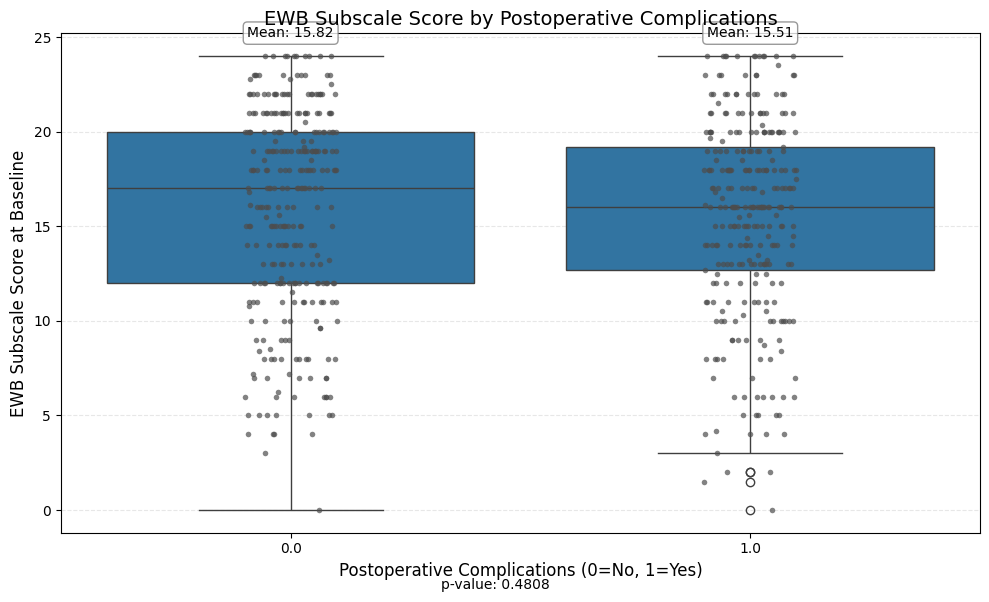

In [ ]:
df = merged_df_removedNA
# Since postop_comp appears to be binary (0.0 or 1.0), we can create a box plot
plt.figure(figsize=(10, 6))

# Create a box plot
ax = sns.boxplot(x='postop_comp', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with some jitter for better visibility
sns.stripplot(x='postop_comp', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.7, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Postoperative Complications', fontsize=14)
plt.xlabel('Postoperative Complications (0=No, 1=Yes)', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and show mean values for each group
for i, comp in enumerate([0, 1]):
    subset = df[df['postop_comp'] == comp]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'Mean: {mean_val:.2f}', ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Add statistical test p-value
from scipy import stats
comp_0 = df[df['postop_comp'] == 0]['ewb_subscale_score_baseline'].dropna()
comp_1 = df[df['postop_comp'] == 1]['ewb_subscale_score_baseline'].dropna()
if len(comp_0) > 0 and len(comp_1) > 0:
    stat, p_value = stats.ttest_ind(comp_0, comp_1, equal_var=False)
    plt.figtext(0.5, 0.01, f'p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
from scipy import stats
from statsmodels.formula.api import glm


# Create a function to analyze the association between EWB scores and postop complications
def analyze_ewb_postop_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and postoperative complications
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Model Results)
    """

    df = data_path.copy()
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['postop_comp'] = pd.to_numeric(df['postop_comp'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'postop_comp'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Basic descriptive statistics
    print("\n--- Descriptive Statistics ---")
    comp_group = df_clean[df_clean['postop_comp'] == 1.0]
    no_comp_group = df_clean[df_clean['postop_comp'] == 0.0]
    
    print(f"Patients with complications (n={len(comp_group)}): ", end="")
    print(f"Mean EWB = {comp_group['ewb_subscale_score_baseline'].mean():.2f}, ", end="")
    print(f"SD = {comp_group['ewb_subscale_score_baseline'].std():.2f}")
    
    print(f"Patients without complications (n={len(no_comp_group)}): ", end="")
    print(f"Mean EWB = {no_comp_group['ewb_subscale_score_baseline'].mean():.2f}, ", end="")
    print(f"SD = {no_comp_group['ewb_subscale_score_baseline'].std():.2f}")
    
    # T-test for difference in means
    t_stat, p_value = stats.ttest_ind(
        comp_group['ewb_subscale_score_baseline'],
        no_comp_group['ewb_subscale_score_baseline'],
        equal_var=False  # Using Welch's t-test which doesn't assume equal variances
    )
    
    print("\n--- Independent Samples T-Test ---")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
    
    # Mann-Whitney U test (non-parametric alternative)
    u_stat, p_value_mw = stats.mannwhitneyu(
        comp_group['ewb_subscale_score_baseline'],
        no_comp_group['ewb_subscale_score_baseline'],
        alternative='less'
    )
    
    print("\n--- Mann-Whitney U Test ---")
    print(f"U-statistic: {u_stat:.4f}")
    print(f"p-value: {p_value_mw:.4f}")
    print(f"Statistically significant: {'Yes' if p_value_mw < 0.05 else 'No'}")
    
    # Logistic regression
    print("\n--- Logistic Regression Analysis ---")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['ewb_subscale_score_baseline'])
    y = df_clean['postop_comp']
    
    # Fit logistic regression model
    model = sm.Logit(y, X)
    results = model.fit(disp=0)  # disp=0 suppresses convergence messages
    
    print(results.summary())
    
    # Extract odds ratio and confidence intervals
    params = results.params
    conf = results.conf_int()
    conf['OR'] = params
    conf.columns = ['2.5%', '97.5%', 'OR']
    conf['OR'] = np.exp(conf['OR'])
    conf['2.5%'] = np.exp(conf['2.5%'])
    conf['97.5%'] = np.exp(conf['97.5%'])
    
    print("\n--- Odds Ratios ---")
    print(conf)
    
    # Interpreting the results
    ewb_coef = results.params['ewb_subscale_score_baseline']
    ewb_pvalue = results.pvalues['ewb_subscale_score_baseline']
    ewb_or = np.exp(ewb_coef)
    
    print("\n--- Interpretation ---")
    if ewb_pvalue < 0.05:
        print(f"EWB score is significantly associated with postoperative complications (p={ewb_pvalue:.4f})")
        if ewb_coef > 0:
            print(f"Higher EWB scores are associated with INCREASED odds of complications")
            print(f"For each 1-point increase in EWB score, the odds of complications increase by {(ewb_or-1)*100:.1f}%")
        else:
            print(f"Higher EWB scores are associated with DECREASED odds of complications")
            print(f"For each 1-point increase in EWB score, the odds of complications decrease by {(1-ewb_or)*100:.1f}%")
    else:
        print(f"EWB score is NOT significantly associated with postoperative complications (p={ewb_pvalue:.4f})")
    
    return df_clean, results


df, results = analyze_ewb_postop_association(merged_df_removedNA)

Analysis based on 590 complete cases

--- Descriptive Statistics ---
Patients with complications (n=289): Mean EWB = 15.51, SD = 5.20
Patients without complications (n=301): Mean EWB = 15.82, SD = 5.42

--- Independent Samples T-Test ---
t-statistic: -0.7054
p-value: 0.4808
Statistically significant: No

--- Mann-Whitney U Test ---
U-statistic: 41430.0000
p-value: 0.1590
Statistically significant: No

--- Logistic Regression Analysis ---
                           Logit Regression Results                           
Dep. Variable:            postop_comp   No. Observations:                  590
Model:                          Logit   Df Residuals:                      588
Method:                           MLE   Df Model:                            1
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:               0.0006092
Time:                        10:53:49   Log-Likelihood:                -408.59
converged:                       True   LL-Null:                       -408.83
Covar

# statistically significantly associated with 2) hospital length of stay (los)

In [11]:
# Merge score_comparison with los data
merged_df_los = score_comparison.merge(df_extracted[["id", "los"]], on="id", how="left")

# Remove rows where los is missing
merged_df_removedNA_los = merged_df_los.dropna(subset=["los"])
merged_df_expanded_los = merged_df_removedNA_los.drop_duplicates()
merged_df_removedNA_los = merged_df_expanded_los.copy()
merged_df_removedNA_los

,id,baseline_type,ewb_subscale_score_baseline,los
0,2,baseline_arm_1,14.0,9.0
6,3,baseline_arm_1,14.0,42.0
20,4,baseline_arm_1,23.0,21.0
26,7,baseline_arm_1,5.0,0.0
27,7,baseline_arm_1,5.0,9.0
...,...,...,...,...
5888,1687,baseline_arm_1,10.0,20.0
5922,1701,baseline_arm_1,23.0,28.0
6053,1748,baseline_arm_1,9.0,17.0
6054,1748,baseline_arm_1,9.0,7.0


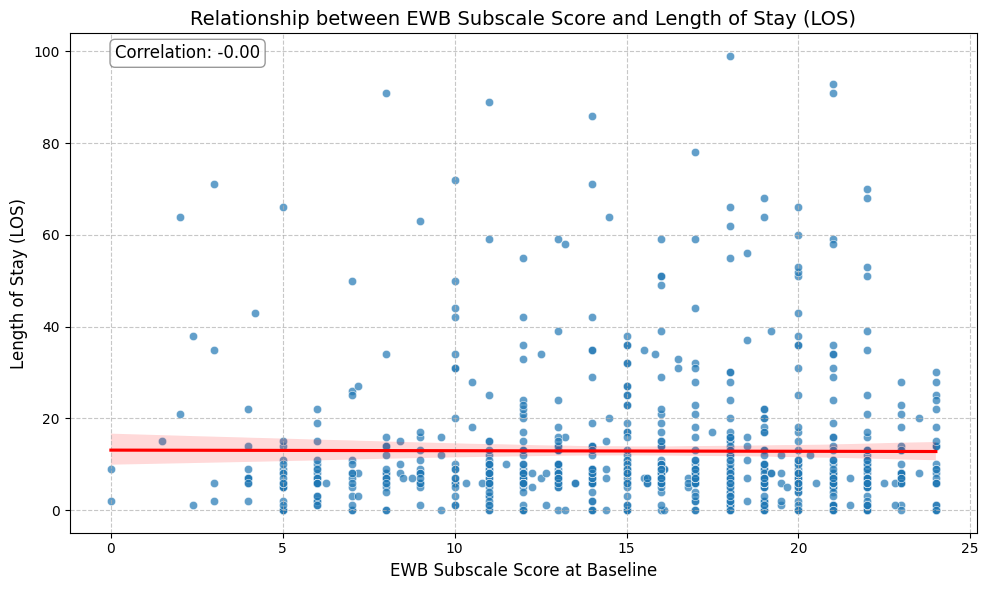

In [12]:
df = merged_df_removedNA_los.copy()

# Create a scatter plot with seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ewb_subscale_score_baseline', y='los', data=df, alpha=0.7)

# Add a regression line to see the relationship
sns.regplot(x='ewb_subscale_score_baseline', y='los', data=df, scatter=False, color='red')

# Improve the appearance
plt.title('Relationship between EWB Subscale Score and Length of Stay (LOS)', fontsize=14)
plt.xlabel('EWB Subscale Score at Baseline', fontsize=12)
plt.ylabel('Length of Stay (LOS)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add correlation coefficient as text
corr = df['ewb_subscale_score_baseline'].corr(df['los'])
plt.annotate(f'Correlation: {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

In [13]:

from statsmodels.formula.api import ols


def analyze_ewb_los_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and length of stay (LOS)
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Model Results)
    """
    # Load data if provided as a path
    df = merged_df_removedNA_los.copy()

    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['los'] = pd.to_numeric(df['los'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'los'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Basic descriptive statistics
    print("\n--- Descriptive Statistics ---")
    print("EWB Subscale Score:")
    print(f"  Mean: {df_clean['ewb_subscale_score_baseline'].mean():.2f}")
    print(f"  Median: {df_clean['ewb_subscale_score_baseline'].median():.2f}")
    print(f"  SD: {df_clean['ewb_subscale_score_baseline'].std():.2f}")
    print(f"  Range: {df_clean['ewb_subscale_score_baseline'].min():.2f} - {df_clean['ewb_subscale_score_baseline'].max():.2f}")
    
    print("\nLength of Stay (LOS):")
    print(f"  Mean: {df_clean['los'].mean():.2f}")
    print(f"  Median: {df_clean['los'].median():.2f}")
    print(f"  SD: {df_clean['los'].std():.2f}")
    print(f"  Range: {df_clean['los'].min():.2f} - {df_clean['los'].max():.2f}")
    
    # Calculate Pearson correlation
    corr, p_value = stats.pearsonr(df_clean['ewb_subscale_score_baseline'], df_clean['los'])
    
    print("\n--- Pearson Correlation ---")
    print(f"Correlation coefficient (r): {corr:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
    
    # Calculate Spearman rank correlation (non-parametric alternative)
    spearman_corr, spearman_p = stats.spearmanr(df_clean['ewb_subscale_score_baseline'], df_clean['los'])
    
    print("\n--- Spearman Rank Correlation ---")
    print(f"Correlation coefficient (rho): {spearman_corr:.4f}")
    print(f"p-value: {spearman_p:.4f}")
    print(f"Statistically significant: {'Yes' if spearman_p < 0.05 else 'No'}")
    
    # Linear regression
    print("\n--- Linear Regression Analysis ---")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['ewb_subscale_score_baseline'])
    y = df_clean['los']
    
    # Fit linear regression model
    model = sm.OLS(y, X)
    results = model.fit()
    
    print(results.summary())
    
    # Coefficient interpretation
    ewb_coef = results.params['ewb_subscale_score_baseline']
    ewb_pvalue = results.pvalues['ewb_subscale_score_baseline']
    
    print("\n--- Interpretation ---")
    if ewb_pvalue < 0.05:
        print(f"EWB score is significantly associated with length of stay (p={ewb_pvalue:.4f})")
        if ewb_coef > 0:
            print(f"Higher EWB scores are associated with LONGER length of stay")
            print(f"For each 1-point increase in EWB score, length of stay increases by {ewb_coef:.2f} days")
        else:
            print(f"Higher EWB scores are associated with SHORTER length of stay")
            print(f"For each 1-point increase in EWB score, length of stay decreases by {abs(ewb_coef):.2f} days")
    else:
        print(f"EWB score is NOT significantly associated with length of stay (p={ewb_pvalue:.4f})")
    
    # Calculate R-squared
    print(f"\nR-squared: {results.rsquared:.4f}")
    print(f"This means that {results.rsquared*100:.1f}% of the variation in length of stay")
    print(f"can be explained by the EWB subscale score.")
    
    return df_clean, results

# If you have your own data:
df, results = analyze_ewb_los_association(merged_df_removedNA_los)

Analysis based on 806 complete cases

--- Descriptive Statistics ---
EWB Subscale Score:
  Mean: 15.54
  Median: 16.00
  SD: 5.30
  Range: 0.00 - 24.00

Length of Stay (LOS):
  Mean: 12.87
  Median: 8.00
  SD: 15.11
  Range: 0.00 - 99.00

--- Pearson Correlation ---
Correlation coefficient (r): -0.0044
p-value: 0.8998
Statistically significant: No

--- Spearman Rank Correlation ---
Correlation coefficient (rho): -0.0148
p-value: 0.6750
Statistically significant: No

--- Linear Regression Analysis ---
                            OLS Regression Results                            
Dep. Variable:                    los   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.01587
Date:                Wed, 09 Apr 2025   Prob (F-statistic):              0.900
Time:                        10:53:51   Log-Likelihood:                -3331.9
No. Observations:   

# statistically significantly associated with 3) 30-day hospital readmission rate (readmission_30d)

In [14]:
# Merge score_comparison with readmission_30d data
merged_df_30re = score_comparison.merge(df_extracted[["id", "readmission_30d"]], on="id", how="left")

# Remove rows where readmission_30d is missing
merged_df_removedNA_30re = merged_df_30re.dropna(subset=["readmission_30d"])

# Identify ids that have both 0 and 1 for readmission_30d
id_counts = merged_df_removedNA_30re.groupby("id")["readmission_30d"].nunique()
ids_with_both = id_counts[id_counts > 1].index

# Remove rows where readmission_30d is 0 for those ids
merged_df_removedNA_30re = merged_df_removedNA_30re[
    ~(merged_df_removedNA_30re["id"].isin(ids_with_both) & (merged_df_removedNA_30re["readmission_30d"] == 0))
]

# Drop duplicates
merged_df_removedNA_30re = merged_df_removedNA_30re.drop_duplicates().copy()

merged_df_removedNA_30re


,id,baseline_type,ewb_subscale_score_baseline,readmission_30d
2,2,baseline_arm_1,14.0,1.0
9,3,baseline_arm_1,14.0,0.0
21,7,baseline_arm_1,5.0,0.0
35,9,baseline_arm_1,20.0,0.0
43,12,baseline_arm_1,14.0,0.0
...,...,...,...,...
5872,1683,baseline_arm_1,16.0,0.0
5888,1687,baseline_arm_1,10.0,1.0
5922,1701,baseline_arm_1,23.0,0.0
5939,1705,baseline_arm_1,23.0,0.0


In [15]:

from statsmodels.formula.api import glm

def analyze_ewb_readmission_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and 30-day readmission
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Model Results)
    """
    # Load data if provided as a path
    df = data_path.copy()
    
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['readmission_30d'] = pd.to_numeric(df['readmission_30d'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'readmission_30d'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Basic descriptive statistics
    print("\n--- Descriptive Statistics ---")
    readmit_group = df_clean[df_clean['readmission_30d'] == 1.0]
    no_readmit_group = df_clean[df_clean['readmission_30d'] == 0.0]
    
    print(f"Patients with 30-day readmission (n={len(readmit_group)}): ", end="")
    print(f"Mean EWB = {readmit_group['ewb_subscale_score_baseline'].mean():.2f}, ", end="")
    print(f"SD = {readmit_group['ewb_subscale_score_baseline'].std():.2f}")
    
    print(f"Patients without 30-day readmission (n={len(no_readmit_group)}): ", end="")
    print(f"Mean EWB = {no_readmit_group['ewb_subscale_score_baseline'].mean():.2f}, ", end="")
    print(f"SD = {no_readmit_group['ewb_subscale_score_baseline'].std():.2f}")
    
    # T-test for difference in means
    if len(readmit_group) > 1 and len(no_readmit_group) > 1:
        t_stat, p_value = stats.ttest_ind(
            readmit_group['ewb_subscale_score_baseline'],
            no_readmit_group['ewb_subscale_score_baseline'],
            equal_var=False  # Using Welch's t-test which doesn't assume equal variances
        )
        
        print("\n--- Independent Samples T-Test ---")
        print(f"t-statistic: {t_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
    else:
        print("\nCannot perform t-test: Need at least 2 samples in each group")
    
    # Mann-Whitney U test (non-parametric alternative)
    if len(readmit_group) > 0 and len(no_readmit_group) > 0:
        u_stat, p_value_mw = stats.mannwhitneyu(
            readmit_group['ewb_subscale_score_baseline'],
            no_readmit_group['ewb_subscale_score_baseline'],
            alternative='two-sided'
        )
        
        print("\n--- Mann-Whitney U Test ---")
        print(f"U-statistic: {u_stat:.4f}")
        print(f"p-value: {p_value_mw:.4f}")
        print(f"Statistically significant: {'Yes' if p_value_mw < 0.05 else 'No'}")
    else:
        print("\nCannot perform Mann-Whitney U test: Need at least 1 sample in each group")
    
    # Logistic regression
    print("\n--- Logistic Regression Analysis ---")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['ewb_subscale_score_baseline'])
    y = df_clean['readmission_30d']
    
    # Fit logistic regression model
    model = sm.Logit(y, X)
    results = model.fit(disp=0)  # disp=0 suppresses convergence messages
    
    print(results.summary())
    
    # Extract odds ratio and confidence intervals
    params = results.params
    conf = results.conf_int()
    conf['OR'] = params
    conf.columns = ['2.5%', '97.5%', 'OR']
    conf['OR'] = np.exp(conf['OR'])
    conf['2.5%'] = np.exp(conf['2.5%'])
    conf['97.5%'] = np.exp(conf['97.5%'])
    
    print("\n--- Odds Ratios ---")
    print(conf)
    
    # Interpreting the results
    ewb_coef = results.params['ewb_subscale_score_baseline']
    ewb_pvalue = results.pvalues['ewb_subscale_score_baseline']
    ewb_or = np.exp(ewb_coef)
    
    print("\n--- Interpretation ---")
    if ewb_pvalue < 0.05:
        print(f"EWB score is significantly associated with 30-day readmission (p={ewb_pvalue:.4f})")
        if ewb_coef > 0:
            print(f"Higher EWB scores are associated with INCREASED odds of 30-day readmission")
            print(f"For each 1-point increase in EWB score, the odds of 30-day readmission increase by {(ewb_or-1)*100:.1f}%")
        else:
            print(f"Higher EWB scores are associated with DECREASED odds of 30-day readmission")
            print(f"For each 1-point increase in EWB score, the odds of 30-day readmission decrease by {(1-ewb_or)*100:.1f}%")
    else:
        print(f"EWB score is NOT significantly associated with 30-day readmission (p={ewb_pvalue:.4f})")
    
    # Calculate McFadden's pseudo R-squared
    print(f"\nMcFadden's Pseudo R-squared: {results.prsquared:.4f}")
    print(f"This provides a measure of model fit (values between 0.2-0.4 indicate excellent fit)")
    
    return df_clean, results

# If you have your own data:
df, results = analyze_ewb_readmission_association(merged_df_removedNA_30re)

Analysis based on 507 complete cases

--- Descriptive Statistics ---
Patients with 30-day readmission (n=76): Mean EWB = 15.06, SD = 4.99
Patients without 30-day readmission (n=431): Mean EWB = 15.58, SD = 5.32

--- Independent Samples T-Test ---
t-statistic: -0.8254
p-value: 0.4110
Statistically significant: No

--- Mann-Whitney U Test ---
U-statistic: 15298.5000
p-value: 0.3589
Statistically significant: No

--- Logistic Regression Analysis ---
                           Logit Regression Results                           
Dep. Variable:        readmission_30d   No. Observations:                  507
Model:                          Logit   Df Residuals:                      505
Method:                           MLE   Df Model:                            1
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                0.001443
Time:                        11:06:57   Log-Likelihood:                -213.92
converged:                       True   LL-Null:                       -214

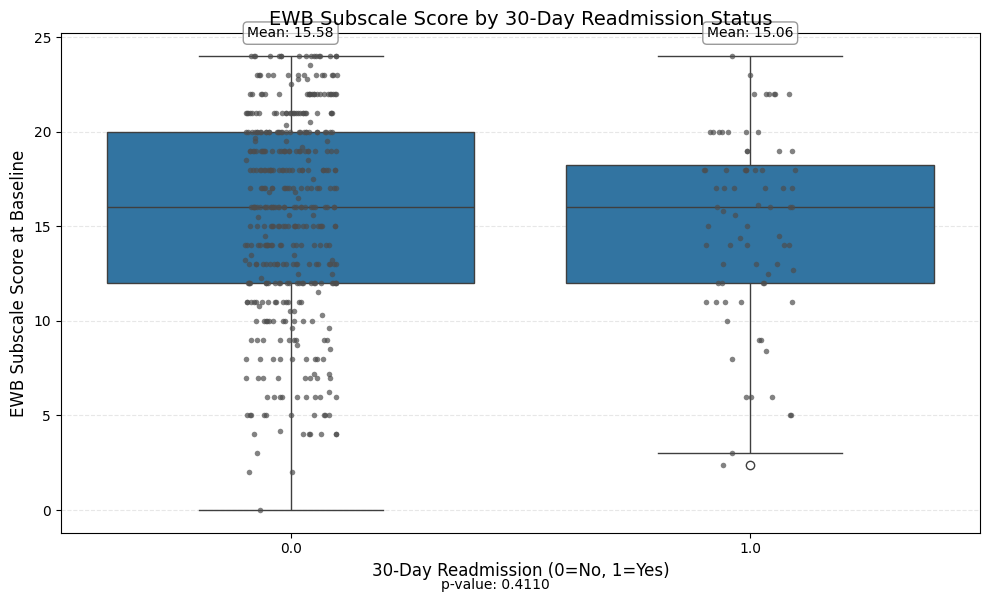

/tmp/ipykernel_64923/3539085472.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  readm_rates = df.groupby('ewb_bin')['readmission_30d'].mean() * 100


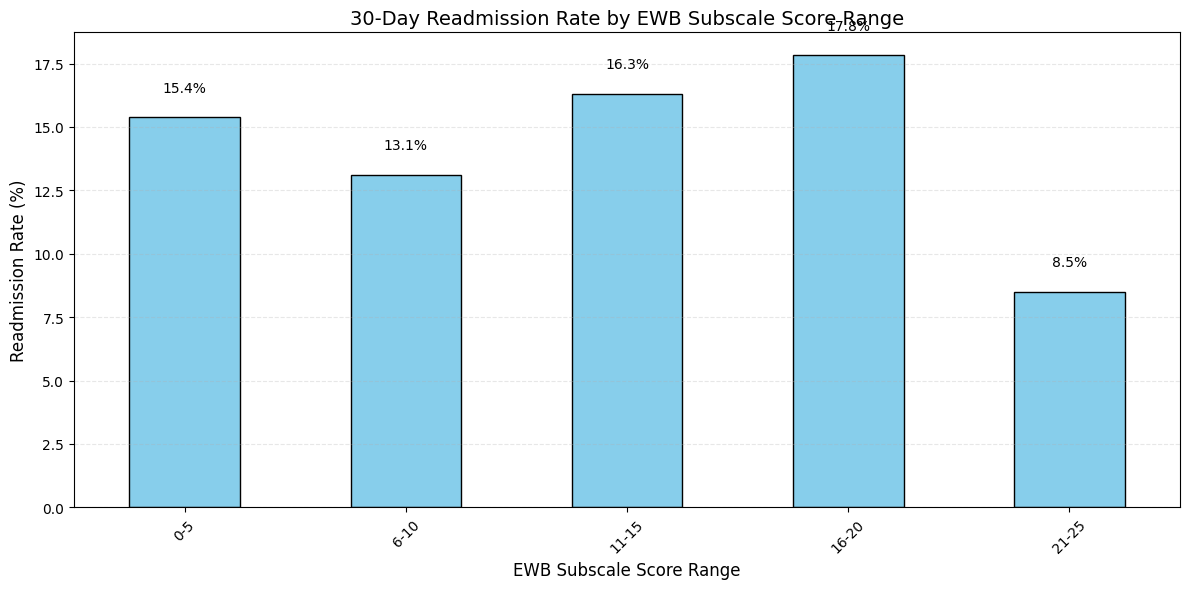

In [16]:

df = merged_df_removedNA_30re

# Since readmission_30d is binary (0.0 or 1.0), we'll create a box plot
plt.figure(figsize=(10, 6))

# Create box plot
sns.boxplot(x='readmission_30d', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='readmission_30d', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.7, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by 30-Day Readmission Status', fontsize=14)
plt.xlabel('30-Day Readmission (0=No, 1=Yes)', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display mean values for each group
for i, readm in enumerate([0, 1]):
    subset = df[df['readmission_30d'] == readm]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'Mean: {mean_val:.2f}', ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform statistical test
readm_0 = df[df['readmission_30d'] == 0]['ewb_subscale_score_baseline'].dropna()
readm_1 = df[df['readmission_30d'] == 1]['ewb_subscale_score_baseline'].dropna()
if len(readm_0) > 0 and len(readm_1) > 0:
    stat, p_value = stats.ttest_ind(readm_0, readm_1, equal_var=False)
    plt.figtext(0.5, 0.01, f'p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('ewb_readmission_30d.png', dpi=300)
plt.show()

# Additionally, create a bar chart showing readmission rates by EWB score ranges
plt.figure(figsize=(12, 6))

# Create bins for EWB scores
bins = [0, 5, 10, 15, 20, 25]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25']
df['ewb_bin'] = pd.cut(df['ewb_subscale_score_baseline'], bins=bins, labels=labels, include_lowest=True)

# Calculate readmission rate for each bin
readm_rates = df.groupby('ewb_bin')['readmission_30d'].mean() * 100

# Create bar chart
readm_rates.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('30-Day Readmission Rate by EWB Subscale Score Range', fontsize=14)
plt.xlabel('EWB Subscale Score Range', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.xticks(rotation=45)

# Add rate values on top of bars
for i, rate in enumerate(readm_rates):
    plt.text(i, rate + 1, f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# statistically significantly associated with 4) age (age_diagnosis)

In [17]:
# Merge score_comparison with los data
merged_df_age = score_comparison.merge(df_extracted[["id", "age_diagnosis"]], on="id", how="left")

# Remove rows where los is missing
merged_df_removedNA_age = merged_df_age.dropna(subset=["age_diagnosis"])
merged_df_expanded_age = merged_df_removedNA_age.drop_duplicates()
merged_df_removedNA_age = merged_df_expanded_age.copy()
merged_df_removedNA_age

,id,baseline_type,ewb_subscale_score_baseline,age_diagnosis
10,3,baseline_arm_1,14.0,70.878937
19,4,baseline_arm_1,23.0,51.078279
73,20,baseline_arm_1,16.0,59.771248
100,26,baseline_arm_1,22.0,57.038817
114,27,baseline_arm_1,24.0,71.987789
...,...,...,...,...
6076,1759,baseline_arm_1,18.0,76.499860
6080,1760,baseline_arm_1,14.0,69.022636
6086,1762,baseline_arm_1,21.0,66.150571
6090,1765,baseline_arm_1,15.0,69.614024


In [18]:

def analyze_ewb_age_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and age at diagnosis
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Model Results)
    """
    # Load data if provided as a path
    df = data_path.copy()
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['age_diagnosis'] = pd.to_numeric(df['age_diagnosis'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'age_diagnosis'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Basic descriptive statistics
    print("\n--- Descriptive Statistics ---")
    print("EWB Subscale Score:")
    print(f"  Mean: {df_clean['ewb_subscale_score_baseline'].mean():.2f}")
    print(f"  Median: {df_clean['ewb_subscale_score_baseline'].median():.2f}")
    print(f"  SD: {df_clean['ewb_subscale_score_baseline'].std():.2f}")
    print(f"  Range: {df_clean['ewb_subscale_score_baseline'].min():.2f} - {df_clean['ewb_subscale_score_baseline'].max():.2f}")
    
    print("\nAge at Diagnosis:")
    print(f"  Mean: {df_clean['age_diagnosis'].mean():.2f}")
    print(f"  Median: {df_clean['age_diagnosis'].median():.2f}")
    print(f"  SD: {df_clean['age_diagnosis'].std():.2f}")
    print(f"  Range: {df_clean['age_diagnosis'].min():.2f} - {df_clean['age_diagnosis'].max():.2f}")
    
    # Calculate Pearson correlation
    corr, p_value = stats.pearsonr(df_clean['ewb_subscale_score_baseline'], df_clean['age_diagnosis'])
    
    print("\n--- Pearson Correlation ---")
    print(f"Correlation coefficient (r): {corr:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
    
    # Calculate Spearman rank correlation (non-parametric alternative)
    spearman_corr, spearman_p = stats.spearmanr(df_clean['ewb_subscale_score_baseline'], df_clean['age_diagnosis'])
    
    print("\n--- Spearman Rank Correlation ---")
    print(f"Correlation coefficient (rho): {spearman_corr:.4f}")
    print(f"p-value: {spearman_p:.4f}")
    print(f"Statistically significant: {'Yes' if spearman_p < 0.05 else 'No'}")
    
    # Linear regression
    print("\n--- Linear Regression Analysis ---")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['ewb_subscale_score_baseline'])
    y = df_clean['age_diagnosis']
    
    # Fit linear regression model
    model = sm.OLS(y, X)
    results = model.fit()
    
    print(results.summary())
    
    # Coefficient interpretation
    ewb_coef = results.params['ewb_subscale_score_baseline']
    ewb_pvalue = results.pvalues['ewb_subscale_score_baseline']
    
    print("\n--- Interpretation ---")
    if ewb_pvalue < 0.05:
        print(f"EWB score is significantly associated with age at diagnosis (p={ewb_pvalue:.4f})")
        if ewb_coef > 0:
            print(f"Higher EWB scores are associated with OLDER age at diagnosis")
            print(f"For each 1-point increase in EWB score, age at diagnosis increases by {ewb_coef:.2f} years")
        else:
            print(f"Higher EWB scores are associated with YOUNGER age at diagnosis")
            print(f"For each 1-point increase in EWB score, age at diagnosis decreases by {abs(ewb_coef):.2f} years")
    else:
        print(f"EWB score is NOT significantly associated with age at diagnosis (p={ewb_pvalue:.4f})")
    
    # Calculate R-squared
    print(f"\nR-squared: {results.rsquared:.4f}")
    print(f"This means that {results.rsquared*100:.1f}% of the variation in age at diagnosis")
    print(f"can be explained by the EWB subscale score.")
    
    # Adjusted R-squared
    print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
    
    return df_clean, results


df, results = analyze_ewb_age_association(merged_df_removedNA_age)

Analysis based on 622 complete cases

--- Descriptive Statistics ---
EWB Subscale Score:
  Mean: 15.29
  Median: 16.00
  SD: 5.27
  Range: 0.00 - 24.00

Age at Diagnosis:
  Mean: 66.09
  Median: 66.39
  SD: 11.37
  Range: 18.86 - 95.26

--- Pearson Correlation ---
Correlation coefficient (r): 0.0750
p-value: 0.0614
Statistically significant: No

--- Spearman Rank Correlation ---
Correlation coefficient (rho): 0.0906
p-value: 0.0239
Statistically significant: Yes

--- Linear Regression Analysis ---
                            OLS Regression Results                            
Dep. Variable:          age_diagnosis   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.511
Date:                Wed, 09 Apr 2025   Prob (F-statistic):             0.0614
Time:                        11:14:33   Log-Likelihood:                -2392.3
No. Observations:      

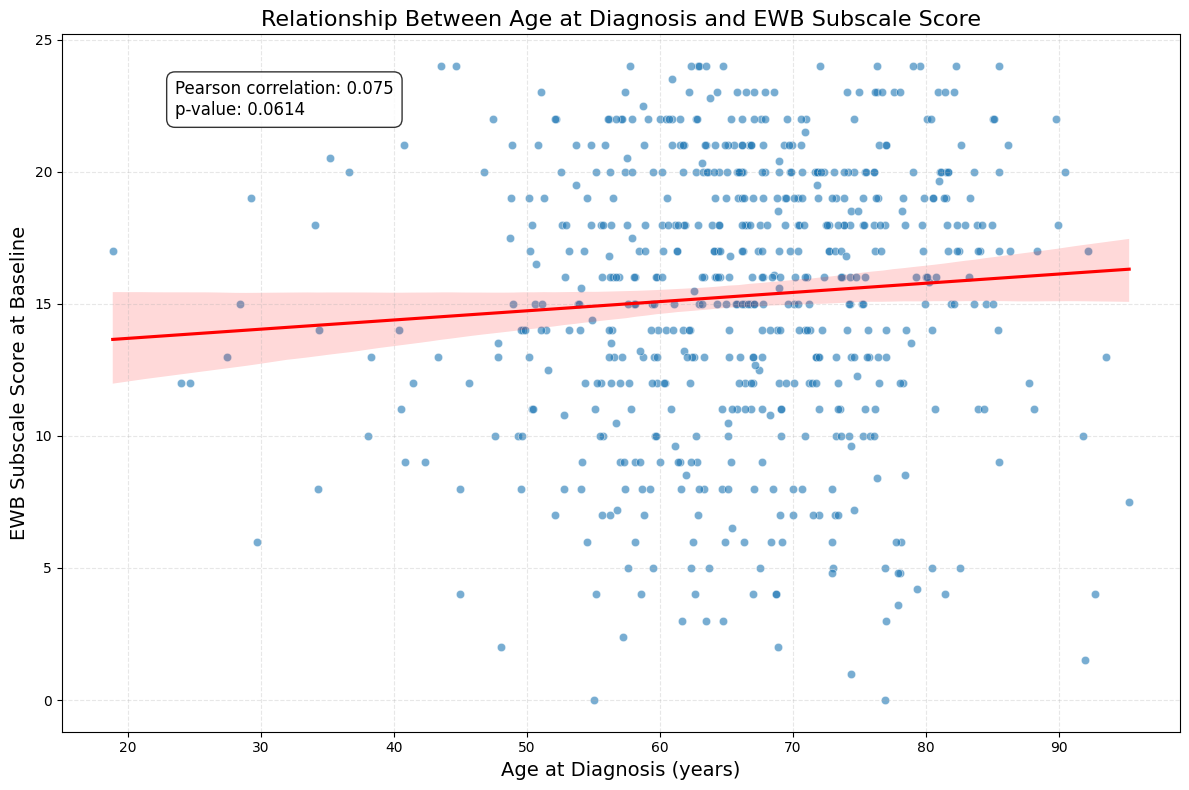

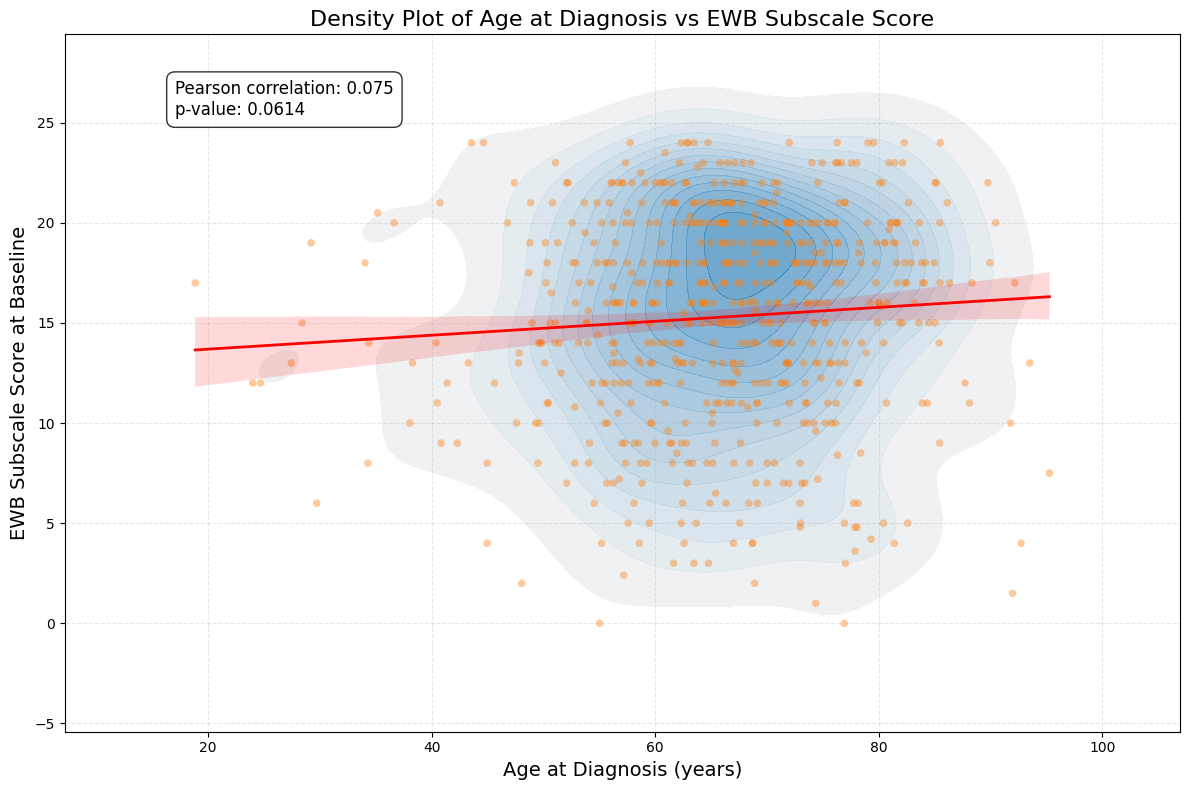

In [19]:

df = merged_df_removedNA_age.copy()

# Create a scatter plot with regression line
plt.figure(figsize=(12, 8))

# Create the scatter plot
sns.scatterplot(x='age_diagnosis', y='ewb_subscale_score_baseline', data=df, alpha=0.6)

# Add regression line with confidence interval
sns.regplot(x='age_diagnosis', y='ewb_subscale_score_baseline', data=df, 
           scatter=False, line_kws={"color":"red"})

# Calculate correlation coefficient and p-value
correlation, p_value = stats.pearsonr(df['age_diagnosis'], df['ewb_subscale_score_baseline'])

# Improve the appearance
plt.title('Relationship Between Age at Diagnosis and EWB Subscale Score', fontsize=16)
plt.xlabel('Age at Diagnosis (years)', fontsize=14)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

# Display correlation information
plt.figtext(0.15, 0.85, f'Pearson correlation: {correlation:.3f}\np-value: {p_value:.4f}', 
           fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Add a density heatmap to show concentration of points
# This is helpful especially if there are many overlapping points
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#f0f0f0', '#2c7fb8'], N=256)
plt.figure(figsize=(12, 8))
sns.kdeplot(data=df, x='age_diagnosis', y='ewb_subscale_score_baseline', 
           fill=True, cmap=cmap, alpha=0.7, levels=15)
sns.scatterplot(x='age_diagnosis', y='ewb_subscale_score_baseline', data=df, 
               alpha=0.4, edgecolor='none', s=30)

# Add regression line
sns.regplot(x='age_diagnosis', y='ewb_subscale_score_baseline', data=df, 
           scatter=False, line_kws={"color":"red", "lw":2})

plt.title('Density Plot of Age at Diagnosis vs EWB Subscale Score', fontsize=16)
plt.xlabel('Age at Diagnosis (years)', fontsize=14)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.figtext(0.15, 0.85, f'Pearson correlation: {correlation:.3f}\np-value: {p_value:.4f}', 
           fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

# Save both figures
plt.figure(1)
plt.tight_layout()

plt.figure(2)
plt.tight_layout()

plt.show()

# statistically significantly associated with 5) sex (gender)

In [20]:
# Merge score_comparison with gender data
merged_df_gender = score_comparison.merge(df_extracted[["id", "gender"]], on="id", how="left")

# Remove rows where gender is missing
merged_df_removedNA_gender = merged_df_gender.dropna(subset=["gender"])
merged_df_expanded_gender = merged_df_removedNA_gender.drop_duplicates()
merged_df_removedNA_gender = merged_df_expanded_gender.copy()
merged_df_removedNA_gender

,id,baseline_type,ewb_subscale_score_baseline,gender
4,2,baseline_arm_1,14.0,1.0
8,3,baseline_arm_1,14.0,2.0
16,4,baseline_arm_1,23.0,1.0
24,7,baseline_arm_1,5.0,1.0
31,8,baseline_arm_1,18.0,1.0
...,...,...,...,...
6083,1762,baseline_arm_1,21.0,1.0
6089,1763,baseline_arm_1,14.0,1.0
6091,1765,baseline_arm_1,15.0,1.0
6093,1766,baseline_arm_1,7.0,1.0


In [21]:


def analyze_ewb_gender_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and gender
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Statistical Test Results)
    """
    df = data_path.copy()
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['gender'] = pd.to_numeric(df['gender'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'gender'])
    
    # Add gender labels for clarity
    df_clean['gender_label'] = df_clean['gender'].map({1.0: 'Male', 2.0: 'Female'})
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Basic descriptive statistics by gender
    print("\n--- Descriptive Statistics by Gender ---")
    stats_by_gender = df_clean.groupby('gender_label')['ewb_subscale_score_baseline'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats_by_gender)
    
    # Separate the data by gender
    male_ewb = df_clean[df_clean['gender'] == 1.0]['ewb_subscale_score_baseline']
    female_ewb = df_clean[df_clean['gender'] == 2.0]['ewb_subscale_score_baseline']
    
    # Independent t-test
    if len(male_ewb) > 1 and len(female_ewb) > 1:
        t_stat, p_value = stats.ttest_ind(
            male_ewb,
            female_ewb,
            equal_var=False  # Using Welch's t-test which doesn't assume equal variances
        )
        
        print("\n--- Independent Samples T-Test ---")
        print(f"t-statistic: {t_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
        
        # Calculate effect size (Cohen's d)
        male_mean = male_ewb.mean()
        female_mean = female_ewb.mean()
        male_std = male_ewb.std()
        female_std = female_ewb.std()
        
        # Pooled standard deviation
        n1, n2 = len(male_ewb), len(female_ewb)
        pooled_std = np.sqrt(((n1 - 1) * male_std**2 + (n2 - 1) * female_std**2) / (n1 + n2 - 2))
        
        # Cohen's d
        cohens_d = abs(male_mean - female_mean) / pooled_std
        
        print(f"Effect size (Cohen's d): {cohens_d:.4f}")
        
        if cohens_d < 0.2:
            effect_size_interp = "negligible"
        elif cohens_d < 0.5:
            effect_size_interp = "small"
        elif cohens_d < 0.8:
            effect_size_interp = "medium"
        else:
            effect_size_interp = "large"
        
        print(f"Effect size interpretation: {effect_size_interp}")
    else:
        print("\nCannot perform t-test: Need at least 2 samples in each gender group")
    
    # Mann-Whitney U test (non-parametric alternative)
    if len(male_ewb) > 0 and len(female_ewb) > 0:
        u_stat, p_value_mw = stats.mannwhitneyu(
            male_ewb,
            female_ewb,
            alternative='two-sided'
        )
        
        print("\n--- Mann-Whitney U Test ---")
        print(f"U-statistic: {u_stat:.4f}")
        print(f"p-value: {p_value_mw:.4f}")
        print(f"Statistically significant: {'Yes' if p_value_mw < 0.05 else 'No'}")
    else:
        print("\nCannot perform Mann-Whitney U test: Need at least 1 sample in each gender group")
    
    # ANOVA (using statsmodels for more comprehensive output)
    print("\n--- One-way ANOVA ---")
    model = ols('ewb_subscale_score_baseline ~ C(gender)', data=df_clean).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    
    # Interpretation
    print("\n--- Interpretation ---")
    if p_value < 0.05:
        higher_group = "males" if male_mean > female_mean else "females"
        print(f"There is a statistically significant difference in EWB scores between males and females (p={p_value:.4f})")
        print(f"On average, {higher_group} have higher EWB scores.")
        print(f"The difference in means is {abs(male_mean - female_mean):.2f} points.")
    else:
        print(f"There is NO statistically significant difference in EWB scores between males and females (p={p_value:.4f})")
        print(f"The difference in means is {abs(male_mean - female_mean):.2f} points, but this difference is not statistically significant.")
    
    return df_clean, (t_stat, p_value) if len(male_ewb) > 1 and len(female_ewb) > 1 else None


df, test_results = analyze_ewb_gender_association(merged_df_removedNA_gender)

Analysis based on 914 complete cases

--- Descriptive Statistics by Gender ---
              count       mean       std  min  median   max
gender_label                                               
Female          212  13.540330  5.506380  1.5    14.0  24.0
Male            702  15.858879  5.161823  0.0    17.0  24.0

--- Independent Samples T-Test ---
t-statistic: 5.4501
p-value: 0.0000
Statistically significant: Yes
Effect size (Cohen's d): 0.4422
Effect size interpretation: small

--- Mann-Whitney U Test ---
U-statistic: 92504.5000
p-value: 0.0000
Statistically significant: Yes

--- One-way ANOVA ---
                 sum_sq     df          F        PR(>F)
C(gender)    875.305003    1.0  31.835233  2.239340e-08
Residual   25075.304551  912.0        NaN           NaN

--- Interpretation ---
There is a statistically significant difference in EWB scores between males and females (p=0.0000)
On average, males have higher EWB scores.
The difference in means is 2.32 points.


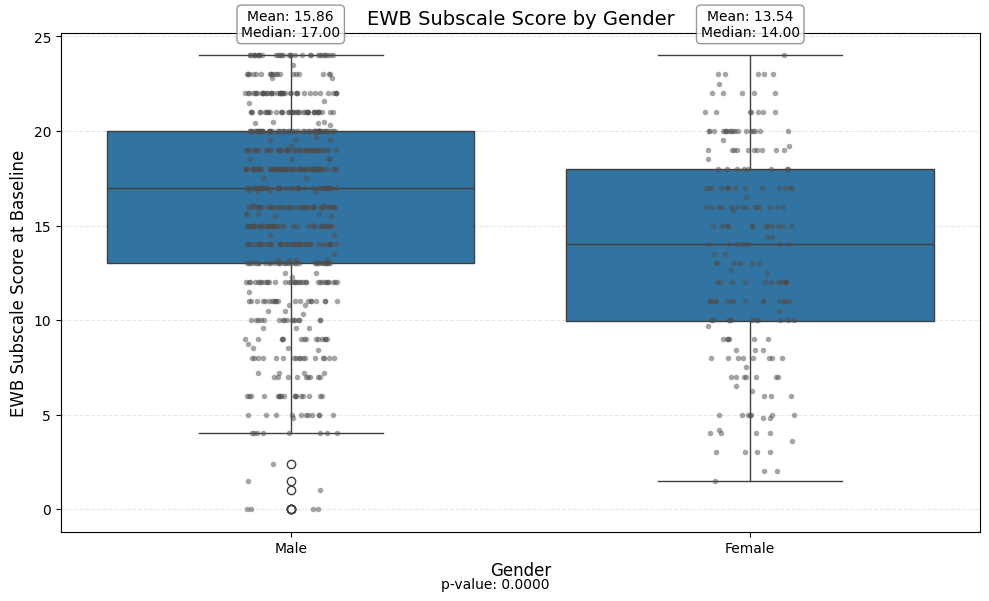

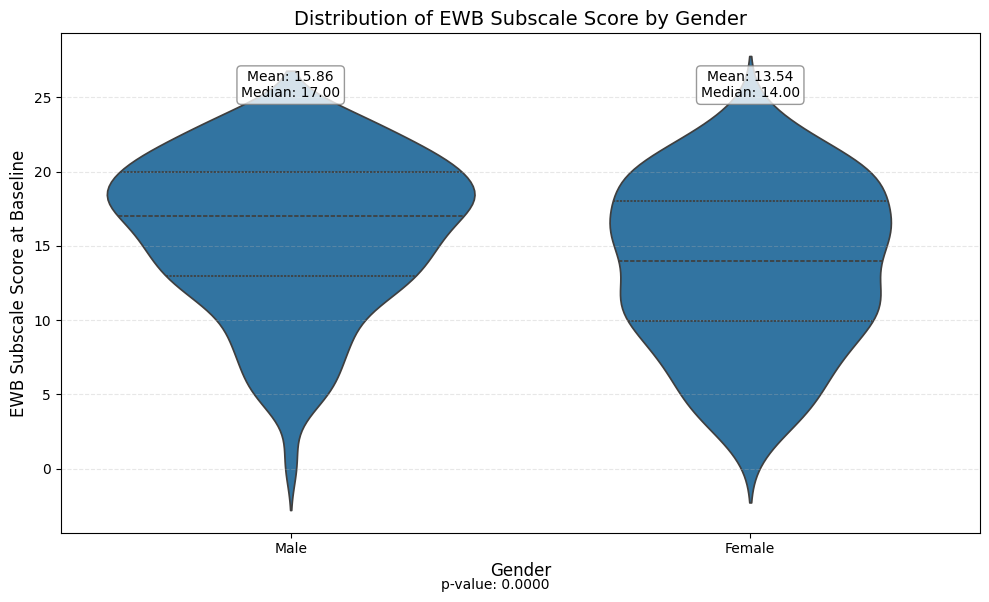

In [23]:

df = merged_df_removedNA_gender.copy()

# It appears gender is encoded as 1.0 and 2.0
# Let's create a more descriptive label (assuming 1=Male, 2=Female)
gender_mapping = {1.0: 'Male', 2.0: 'Female'}
df['gender_label'] = df['gender'].map(gender_mapping)

# Create a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender_label', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='gender_label', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.5, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display summary statistics
for i, gender in enumerate(gender_mapping.values()):
    subset = df[df['gender_label'] == gender]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform statistical test (t-test for independent samples)
gender1 = df[df['gender'] == 1.0]['ewb_subscale_score_baseline'].dropna()
gender2 = df[df['gender'] == 2.0]['ewb_subscale_score_baseline'].dropna()
if len(gender1) > 0 and len(gender2) > 0:
    stat, p_value = stats.ttest_ind(gender1, gender2, equal_var=False)
    plt.figtext(0.5, 0.01, f'p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('ewb_by_gender.png', dpi=300)

# Additionally create a violin plot for better distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(x='gender_label', y='ewb_subscale_score_baseline', data=df, inner='quartile')

plt.title('Distribution of EWB Subscale Score by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add the same statistics
for i, gender in enumerate(gender_mapping.values()):
    subset = df[df['gender_label'] == gender]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.figtext(0.5, 0.01, f'p-value: {p_value:.4f}', ha='center', fontsize=10)
plt.tight_layout()

plt.show()

# statistically significantly associated with 6) clinical staging (overall_primary_tumour)

In [24]:
# Merge score_comparison with overall_primary_tumour data
merged_df_tumor = score_comparison.merge(df_extracted[["id", "overall_primary_tumour"]], on="id", how="left")

# Remove rows where overall_primary_tumour is missing
merged_df_removedNA_tumour = merged_df_tumor.dropna(subset=["overall_primary_tumour"])
merged_df_expanded_tumour = merged_df_removedNA_tumour.drop_duplicates()
merged_df_removedNA_tumour = merged_df_expanded_tumour.copy()
merged_df_removedNA_tumour

,id,baseline_type,ewb_subscale_score_baseline,overall_primary_tumour
5,2,baseline_arm_1,14.0,3
10,3,baseline_arm_1,14.0,3
19,4,baseline_arm_1,23.0,3
22,7,baseline_arm_1,5.0,3
30,8,baseline_arm_1,18.0,4
...,...,...,...,...
6076,1759,baseline_arm_1,18.0,3
6086,1762,baseline_arm_1,21.0,4
6088,1763,baseline_arm_1,14.0,3
6090,1765,baseline_arm_1,15.0,3


In [25]:
# Ensure the "overall_primary_tumour" column is numeric
tumor_mapping = {
    "99": None,  # "X" is unclear; assuming it should be NaN or ignored
    "0": 0, 
    "00": 0, 
    "1": 1, "1a": 1, "1b": 1, 
    "2": 2, 
    "3": 3, 
    "4": 4, "4a": 4, 
    "4b": 4,  # Kept as 4 unless you want it separate
    "5": None  # "Unknown" should be NaN
}

# Apply mapping to convert tumor stage to numeric
merged_df_removedNA_tumour["overall_primary_tumour"] = merged_df_removedNA_tumour["overall_primary_tumour"].map(tumor_mapping)

# Remove any NaN values after mapping
merged_df_removedNA_tumour = merged_df_removedNA_tumour.dropna(subset=["overall_primary_tumour"])
merged_df_removedNA_tumour

,id,baseline_type,ewb_subscale_score_baseline,overall_primary_tumour
5,2,baseline_arm_1,14.0,3.0
10,3,baseline_arm_1,14.0,3.0
19,4,baseline_arm_1,23.0,3.0
22,7,baseline_arm_1,5.0,3.0
30,8,baseline_arm_1,18.0,4.0
...,...,...,...,...
6076,1759,baseline_arm_1,18.0,3.0
6086,1762,baseline_arm_1,21.0,4.0
6088,1763,baseline_arm_1,14.0,3.0
6090,1765,baseline_arm_1,15.0,3.0


In [26]:

def analyze_ewb_tumour_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and overall primary tumour classification
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Statistical Test Results)
    """
    df = data_path.copy()

    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['overall_primary_tumour'] = pd.to_numeric(df['overall_primary_tumour'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'overall_primary_tumour'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Check unique values in overall_primary_tumour
    tumour_categories = sorted(df_clean['overall_primary_tumour'].unique())
    print(f"\nFound {len(tumour_categories)} unique tumour classifications: {tumour_categories}")
    
    # Basic descriptive statistics by tumour classification
    print("\n--- Descriptive Statistics by Tumour Classification ---")
    stats_by_tumour = df_clean.groupby('overall_primary_tumour')['ewb_subscale_score_baseline'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats_by_tumour)
    
    # ANOVA if there are 3 or more groups
    if len(tumour_categories) >= 3:
        print("\n--- One-way ANOVA ---")
        model = ols('ewb_subscale_score_baseline ~ C(overall_primary_tumour)', data=df_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(anova_table)
        
        f_stat = anova_table['F'][0]
        p_value = anova_table['PR(>F)'][0]
        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
        
        # If ANOVA is significant, perform post-hoc tests
        if p_value < 0.05:
            print("\n--- Post-hoc Tests (Tukey HSD) ---")
            from statsmodels.stats.multicomp import pairwise_tukeyhsd
            
            # Prepare data for Tukey's test
            endog = df_clean['ewb_subscale_score_baseline']
            groups = df_clean['overall_primary_tumour']
            
            # Perform Tukey's test
            tukey = pairwise_tukeyhsd(endog=endog, groups=groups, alpha=0.05)
            print(tukey)
    
    # Kruskal-Wallis H-test (non-parametric alternative to ANOVA)
    if len(tumour_categories) >= 3:
        print("\n--- Kruskal-Wallis H Test ---")
        groups = [df_clean[df_clean['overall_primary_tumour'] == cat]['ewb_subscale_score_baseline'] for cat in tumour_categories]
        
        # Only perform test if each group has at least one sample
        if all(len(g) > 0 for g in groups):
            h_stat, p_value_kw = stats.kruskal(*groups)
            
            print(f"H-statistic: {h_stat:.4f}")
            print(f"p-value: {p_value_kw:.4f}")
            print(f"Statistically significant: {'Yes' if p_value_kw < 0.05 else 'No'}")
        else:
            print("Cannot perform Kruskal-Wallis test: Need at least 1 sample in each group")
    
    # If only 2 categories, perform t-test instead of ANOVA
    elif len(tumour_categories) == 2:
        group1 = df_clean[df_clean['overall_primary_tumour'] == tumour_categories[0]]['ewb_subscale_score_baseline']
        group2 = df_clean[df_clean['overall_primary_tumour'] == tumour_categories[1]]['ewb_subscale_score_baseline']
        
        if len(group1) > 1 and len(group2) > 1:
            print(f"\n--- Independent Samples T-Test (Comparing {tumour_categories[0]} vs {tumour_categories[1]}) ---")
            t_stat, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False  # Using Welch's t-test which doesn't assume equal variances
            )
            
            print(f"t-statistic: {t_stat:.4f}")
            print(f"p-value: {p_value:.4f}")
            print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
            
            # Calculate effect size (Cohen's d)
            group1_mean = group1.mean()
            group2_mean = group2.mean()
            group1_std = group1.std()
            group2_std = group2.std()
            
            # Pooled standard deviation
            n1, n2 = len(group1), len(group2)
            pooled_std = np.sqrt(((n1 - 1) * group1_std**2 + (n2 - 1) * group2_std**2) / (n1 + n2 - 2))
            
            # Cohen's d
            cohens_d = abs(group1_mean - group2_mean) / pooled_std
            
            print(f"Effect size (Cohen's d): {cohens_d:.4f}")
    
    # Linear regression (treating tumour classification as continuous for analysis of trend)
    print("\n--- Linear Regression Analysis ---")
    print("Note: This treats tumour classification as a continuous variable to detect linear trends")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['overall_primary_tumour'])
    y = df_clean['ewb_subscale_score_baseline']
    
    # Fit linear regression model
    model = sm.OLS(y, X)
    results = model.fit()
    
    print(results.summary())
    
    # Correlation analysis
    corr, p_value_corr = stats.pearsonr(df_clean['overall_primary_tumour'], df_clean['ewb_subscale_score_baseline'])
    
    print("\n--- Correlation Analysis ---")
    print(f"Pearson correlation coefficient: {corr:.4f}")
    print(f"p-value: {p_value_corr:.4f}")
    print(f"Statistically significant: {'Yes' if p_value_corr < 0.05 else 'No'}")
    
    # Interpretation
    print("\n--- Interpretation ---")
    if len(tumour_categories) >= 3 and p_value < 0.05:
        print(f"There is a statistically significant difference in EWB scores between tumour classifications (p={p_value:.4f})")
        print("See the descriptive statistics table for group means and the post-hoc tests for specific group differences.")
    elif len(tumour_categories) == 2 and p_value < 0.05:
        higher_group = tumour_categories[0] if group1_mean > group2_mean else tumour_categories[1]
        print(f"There is a statistically significant difference in EWB scores between tumour classifications {tumour_categories[0]} and {tumour_categories[1]} (p={p_value:.4f})")
        print(f"On average, patients with tumour classification {higher_group} have higher EWB scores.")
    elif p_value_corr < 0.05:
        direction = "positive" if corr > 0 else "negative"
        print(f"There is a statistically significant {direction} correlation between tumour classification and EWB scores (r={corr:.4f}, p={p_value_corr:.4f})")
        if corr > 0:
            print("As tumour classification increases, EWB scores tend to increase as well.")
        else:
            print("As tumour classification increases, EWB scores tend to decrease.")
    else:
        print(f"There is NO statistically significant association between tumour classification and EWB scores")
        
    return df_clean, results

# If you have your own data:
df, results = analyze_ewb_tumour_association(merged_df_removedNA_tumour)

Analysis based on 758 complete cases

Found 5 unique tumour classifications: [0.0, 1.0, 2.0, 3.0, 4.0]

--- Descriptive Statistics by Tumour Classification ---
                        count       mean       std  min  median   max
overall_primary_tumour                                               
0.0                        28  17.221429  4.249040  8.0   17.00  24.0
1.0                        87  16.798851  5.347494  0.0   18.00  24.0
2.0                        60  15.500000  4.841872  5.0   15.75  24.0
3.0                       536  14.811816  5.371874  0.0   16.00  24.0
4.0                        47  14.539362  5.686329  3.0   15.00  23.5

--- One-way ANOVA ---
                                 sum_sq     df        F    PR(>F)
C(overall_primary_tumour)    442.641707    4.0  3.92022  0.003702
Residual                   21255.769097  753.0      NaN       NaN
F-statistic: 3.9202
p-value: 0.0037
Statistically significant: Yes

--- Post-hoc Tests (Tukey HSD) ---


/tmp/ipykernel_64923/38599765.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/tmp/ipykernel_64923/38599765.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   0.0    1.0  -0.4226 0.9962 -3.5791   2.734  False
   0.0    2.0  -1.7214 0.6177 -5.0464  1.6036  False
   0.0    3.0  -2.4096 0.1337 -5.2259  0.4067  False
   0.0    4.0  -2.6821 0.2148 -6.1503  0.7861  False
   1.0    2.0  -1.2989  0.591 -3.7368  1.1391  False
   1.0    3.0   -1.987 0.0111 -3.6662 -0.3078   True
   1.0    4.0  -2.2595 0.1308 -4.8894  0.3705  False
   2.0    3.0  -0.6882 0.8765 -2.6659  1.2895  False
   2.0    4.0  -0.9606  0.886 -3.7905  1.8693  False
   3.0    4.0  -0.2725 0.9972 -2.4825  1.9376  False
----------------------------------------------------

--- Kruskal-Wallis H Test ---
H-statistic: 16.5734
p-value: 0.0023
Statistically significant: Yes

--- Linear Regression Analysis ---
Note: This treats tumour classification as a continuous variable to detect linear trends
                                 O

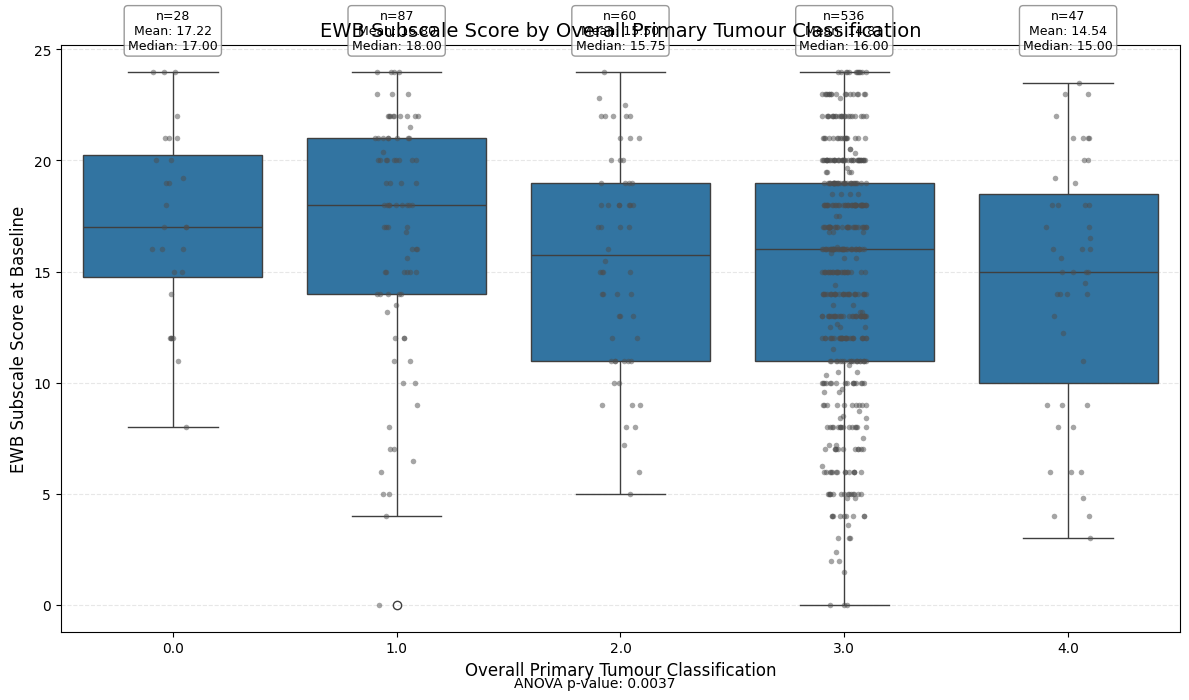

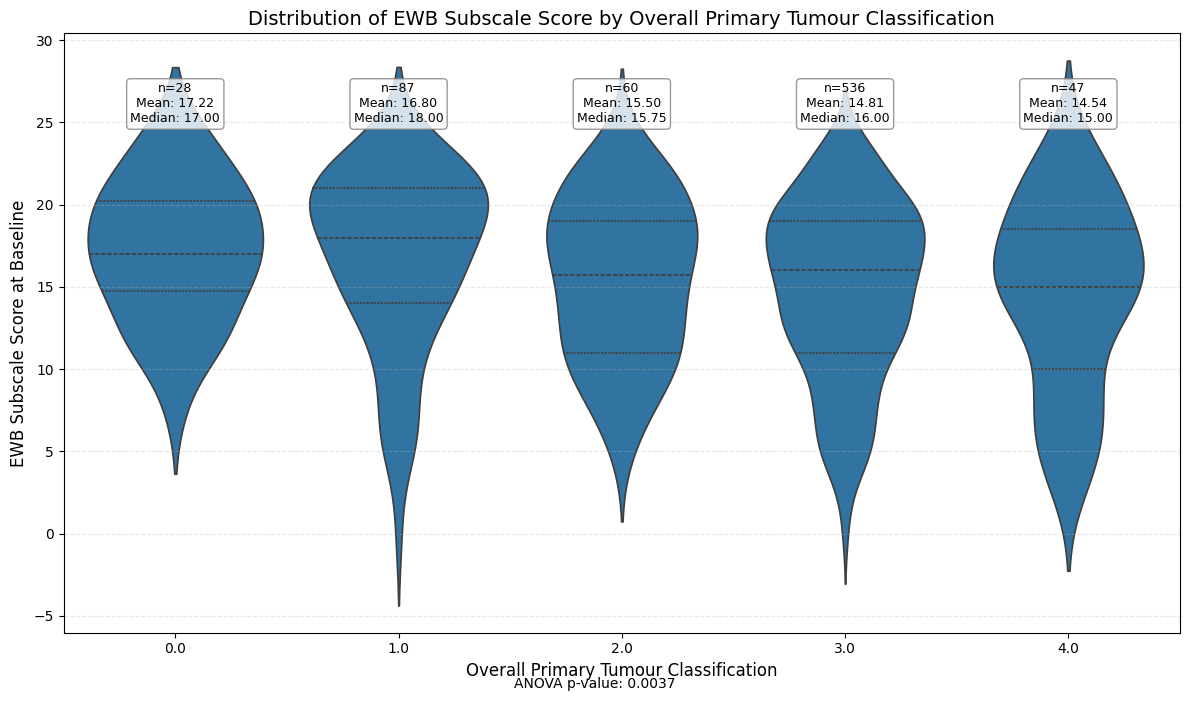

In [27]:

df = merged_df_removedNA_tumour.copy()

# It appears overall_primary_tumour is categorical (1.0, 3.0, 4.0)
# Let's create a boxplot
plt.figure(figsize=(12, 7))

# Create box plot
sns.boxplot(x='overall_primary_tumour', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='overall_primary_tumour', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.5, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Overall Primary Tumour Classification', fontsize=14)
plt.xlabel('Overall Primary Tumour Classification', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display summary statistics for each tumour classification
tumour_classes = df['overall_primary_tumour'].unique()
for i, tumour_class in enumerate(sorted(tumour_classes)):
    subset = df[df['overall_primary_tumour'] == tumour_class]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform statistical test (ANOVA) if there are more than 2 groups
unique_tumours = df['overall_primary_tumour'].unique()
if len(unique_tumours) > 2:
    groups = [df[df['overall_primary_tumour'] == t]['ewb_subscale_score_baseline'].dropna() for t in unique_tumours]
    groups = [g for g in groups if len(g) > 0]  # Remove empty groups
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        plt.figtext(0.5, 0.01, f'ANOVA p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()

# Additionally create a violin plot for better distribution visualization
plt.figure(figsize=(12, 7))
sns.violinplot(x='overall_primary_tumour', y='ewb_subscale_score_baseline', data=df, inner='quartile')

plt.title('Distribution of EWB Subscale Score by Overall Primary Tumour Classification', fontsize=14)
plt.xlabel('Overall Primary Tumour Classification', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add the same statistics
for i, tumour_class in enumerate(sorted(tumour_classes)):
    subset = df[df['overall_primary_tumour'] == tumour_class]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

if len(unique_tumours) > 2:
    plt.figtext(0.5, 0.01, f'ANOVA p-value: {p_value:.4f}', ha='center', fontsize=10)
    
plt.tight_layout()

plt.show()

# statistically significantly associated with 7) clinical staging (overall_regional_ln)

In [28]:
# Merge score_comparison with overall_regional_ln data
merged_df_ln = score_comparison.merge(df_extracted[["id", "overall_regional_ln"]], on="id", how="left")

# Remove rows where overall_regional_ln is missing
merged_df_removedNA_ln = merged_df_ln.dropna(subset=["overall_regional_ln"])
merged_df_expanded_ln = merged_df_removedNA_ln.drop_duplicates()
merged_df_removedNA_ln = merged_df_expanded_ln.copy()
merged_df_removedNA_ln

,id,baseline_type,ewb_subscale_score_baseline,overall_regional_ln
5,2,baseline_arm_1,14.0,1
10,3,baseline_arm_1,14.0,0
19,4,baseline_arm_1,23.0,0
22,7,baseline_arm_1,5.0,3
30,8,baseline_arm_1,18.0,2
...,...,...,...,...
6076,1759,baseline_arm_1,18.0,1
6086,1762,baseline_arm_1,21.0,2
6088,1763,baseline_arm_1,14.0,0
6090,1765,baseline_arm_1,15.0,0


In [29]:
regional_ln_mapping = {
    "99": None,  # "X" likely means unknown/missing
    "0": 0, 
    "1": 1, 
    "2": 2, 
    "3": 3, 
    "4": 4,
    "pos": 1  # Assuming "pos" means lymph node involvement (map to 1) 
}

# Apply mapping to convert ln stage to numeric
merged_df_removedNA_ln["overall_regional_ln"] = merged_df_removedNA_ln["overall_regional_ln"].map(regional_ln_mapping)

# Remove any NaN values after mapping
merged_df_removedNA_ln = merged_df_removedNA_ln.dropna(subset=["overall_regional_ln"])
merged_df_removedNA_ln

,id,baseline_type,ewb_subscale_score_baseline,overall_regional_ln
5,2,baseline_arm_1,14.0,1.0
10,3,baseline_arm_1,14.0,0.0
19,4,baseline_arm_1,23.0,0.0
22,7,baseline_arm_1,5.0,3.0
30,8,baseline_arm_1,18.0,2.0
...,...,...,...,...
6076,1759,baseline_arm_1,18.0,1.0
6086,1762,baseline_arm_1,21.0,2.0
6088,1763,baseline_arm_1,14.0,0.0
6090,1765,baseline_arm_1,15.0,0.0


In [31]:

def analyze_ewb_ln_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and overall regional lymph node status
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Statistical Test Results)
    """
    # Load data if provided as a path
    df = data_path.copy()
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['overall_regional_ln'] = pd.to_numeric(df['overall_regional_ln'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'overall_regional_ln'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Check unique values in overall_regional_ln
    ln_categories = sorted(df_clean['overall_regional_ln'].unique())
    print(f"\nFound {len(ln_categories)} unique lymph node classifications: {ln_categories}")
    
    # Basic descriptive statistics by lymph node status
    print("\n--- Descriptive Statistics by Regional Lymph Node Status ---")
    stats_by_ln = df_clean.groupby('overall_regional_ln')['ewb_subscale_score_baseline'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats_by_ln)
    
    # ANOVA if there are 3 or more groups
    if len(ln_categories) >= 3:
        print("\n--- One-way ANOVA ---")
        model = ols('ewb_subscale_score_baseline ~ C(overall_regional_ln)', data=df_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(anova_table)
        
        f_stat = anova_table['F'][0]
        p_value = anova_table['PR(>F)'][0]
        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
        
        # If ANOVA is significant, perform post-hoc tests
        if p_value < 0.05:
            print("\n--- Post-hoc Tests (Tukey HSD) ---")
            from statsmodels.stats.multicomp import pairwise_tukeyhsd
            
            # Prepare data for Tukey's test
            endog = df_clean['ewb_subscale_score_baseline']
            groups = df_clean['overall_regional_ln']
            
            # Perform Tukey's test
            tukey = pairwise_tukeyhsd(endog=endog, groups=groups, alpha=0.05)
            print(tukey)
    
    # Kruskal-Wallis H-test (non-parametric alternative to ANOVA)
    if len(ln_categories) >= 3:
        print("\n--- Kruskal-Wallis H Test ---")
        groups = [df_clean[df_clean['overall_regional_ln'] == cat]['ewb_subscale_score_baseline'] for cat in ln_categories]
        
        # Only perform test if each group has at least one sample
        if all(len(g) > 0 for g in groups):
            h_stat, p_value_kw = stats.kruskal(*groups)
            
            print(f"H-statistic: {h_stat:.4f}")
            print(f"p-value: {p_value_kw:.4f}")
            print(f"Statistically significant: {'Yes' if p_value_kw < 0.05 else 'No'}")
        else:
            print("Cannot perform Kruskal-Wallis test: Need at least 1 sample in each group")
    
    # If only 2 categories, perform t-test instead of ANOVA
    elif len(ln_categories) == 2:
        group1 = df_clean[df_clean['overall_regional_ln'] == ln_categories[0]]['ewb_subscale_score_baseline']
        group2 = df_clean[df_clean['overall_regional_ln'] == ln_categories[1]]['ewb_subscale_score_baseline']
        
        if len(group1) > 1 and len(group2) > 1:
            print(f"\n--- Independent Samples T-Test (Comparing {ln_categories[0]} vs {ln_categories[1]}) ---")
            t_stat, p_value = stats.ttest_ind(
                group1,
                group2,
                equal_var=False  # Using Welch's t-test which doesn't assume equal variances
            )
            
            print(f"t-statistic: {t_stat:.4f}")
            print(f"p-value: {p_value:.4f}")
            print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
            
            # Calculate effect size (Cohen's d)
            group1_mean = group1.mean()
            group2_mean = group2.mean()
            group1_std = group1.std()
            group2_std = group2.std()
            
            # Pooled standard deviation
            n1, n2 = len(group1), len(group2)
            pooled_std = np.sqrt(((n1 - 1) * group1_std**2 + (n2 - 1) * group2_std**2) / (n1 + n2 - 2))
            
            # Cohen's d
            cohens_d = abs(group1_mean - group2_mean) / pooled_std
            
            print(f"Effect size (Cohen's d): {cohens_d:.4f}")
    
    # Linear regression (treating lymph node status as ordinal for analysis of trend)
    print("\n--- Linear Regression Analysis ---")
    print("Note: This treats lymph node status as a continuous variable to detect linear trends")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['overall_regional_ln'])
    y = df_clean['ewb_subscale_score_baseline']
    
    # Fit linear regression model
    model = sm.OLS(y, X)
    results = model.fit()
    
    print(results.summary())
    
    # Jonckheere-Terpstra test for ordered alternatives
    # This test is appropriate when categories have a natural ordering
    from scipy.stats import mannwhitneyu
    
    print("\n--- Test for Trend Across Ordered Groups ---")
    print("Jonckheere-Terpstra test (implemented using consecutive Mann-Whitney U tests)")
    
    # Implementation of Jonckheere-Terpstra test using pairwise Mann-Whitney U tests
    if len(ln_categories) >= 2:
        # Sort categories to ensure proper ordering
        ln_categories.sort()
        
        # Calculate z-statistic for each consecutive pair
        z_statistics = []
        for i in range(len(ln_categories) - 1):
            cat1 = ln_categories[i]
            cat2 = ln_categories[i + 1]
            
            group1 = df_clean[df_clean['overall_regional_ln'] == cat1]['ewb_subscale_score_baseline']
            group2 = df_clean[df_clean['overall_regional_ln'] == cat2]['ewb_subscale_score_baseline']
            
            if len(group1) > 0 and len(group2) > 0:
                u_stat, p_value = mannwhitneyu(group1, group2, alternative='less')
                # Estimate z-statistic from p-value
                z = stats.norm.ppf(p_value)
                z_statistics.append(z)
                
                print(f"Comparing {cat1} vs {cat2}: p-value = {p_value:.4f}")
        
        # If we have at least one valid comparison
        if z_statistics:
            # Sum z-statistics and normalize
            z_sum = sum(z_statistics)
            trend_p_value = stats.norm.cdf(z_sum / np.sqrt(len(z_statistics)))
            
            print(f"Overall trend p-value: {trend_p_value:.4f}")
            print(f"Evidence for trend: {'Yes' if trend_p_value < 0.05 else 'No'}")
    
    # Correlation analysis
    corr, p_value_corr = stats.spearmanr(df_clean['overall_regional_ln'], df_clean['ewb_subscale_score_baseline'])
    
    print("\n--- Correlation Analysis ---")
    print(f"Spearman rank correlation coefficient: {corr:.4f}")
    print(f"p-value: {p_value_corr:.4f}")
    print(f"Statistically significant: {'Yes' if p_value_corr < 0.05 else 'No'}")
    
    # Interpretation
    print("\n--- Interpretation ---")
    
    if len(ln_categories) >= 3 and p_value < 0.05:
        print(f"There is a statistically significant difference in EWB scores between lymph node status groups (p={p_value:.4f})")
        print("See the descriptive statistics table for group means and the post-hoc tests for specific group differences.")
    elif len(ln_categories) == 2 and p_value < 0.05:
        higher_group = ln_categories[0] if group1_mean > group2_mean else ln_categories[1]
        print(f"There is a statistically significant difference in EWB scores between lymph node status {ln_categories[0]} and {ln_categories[1]} (p={p_value:.4f})")
        print(f"On average, patients with lymph node status {higher_group} have higher EWB scores.")
    
    if p_value_corr < 0.05:
        direction = "positive" if corr > 0 else "negative"
        print(f"There is a statistically significant {direction} correlation between lymph node status and EWB scores")
        print(f"(Spearman's rho={corr:.4f}, p={p_value_corr:.4f})")
        if corr > 0:
            print("As lymph node involvement increases, EWB scores tend to increase as well.")
        else:
            print("As lymph node involvement increases, EWB scores tend to decrease.")
    else:
        print(f"There is NO statistically significant trend or correlation between lymph node status and EWB scores")
        
    return df_clean, results

df, results = analyze_ewb_ln_association(merged_df_removedNA_ln)

Analysis based on 750 complete cases

Found 5 unique lymph node classifications: [0.0, 1.0, 2.0, 3.0, 4.0]

--- Descriptive Statistics by Regional Lymph Node Status ---
                     count       mean       std   min  median   max
overall_regional_ln                                                
0.0                    301  16.011849  4.969321   2.0    17.0  24.0
1.0                    322  14.867029  5.500845   0.0    15.0  24.0
2.0                     57  14.477193  5.262163   4.0    15.0  24.0
3.0                     67  13.067662  5.725626   0.0    13.0  24.0
4.0                      3  14.000000  6.082763  10.0    11.0  21.0

--- One-way ANOVA ---
                              sum_sq     df         F   PR(>F)
C(overall_regional_ln)    569.426109    4.0  5.072052  0.00049
Residual                20909.804368  745.0       NaN      NaN
F-statistic: 5.0721
p-value: 0.0005
Statistically significant: Yes

--- Post-hoc Tests (Tukey HSD) ---


/tmp/ipykernel_64923/1413001891.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/tmp/ipykernel_64923/1413001891.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   0.0    1.0  -1.1448 0.0556  -2.3063  0.0166  False
   0.0    2.0  -1.5347 0.2643  -3.6273   0.558  False
   0.0    3.0  -2.9442 0.0004  -4.9011 -0.9873   True
   0.0    4.0  -2.0118 0.9658 -10.4173  6.3936  False
   1.0    2.0  -0.3898 0.9862  -2.4716  1.6919  False
   1.0    3.0  -1.7994 0.0853  -3.7446  0.1459  False
   1.0    4.0   -0.867 0.9986  -9.2698  7.5358  False
   2.0    3.0  -1.4095 0.5781  -4.0199  1.2009  False
   2.0    4.0  -0.4772 0.9999  -9.0584   8.104  False
   3.0    4.0   0.9323 0.9983  -7.6168  9.4814  False
-----------------------------------------------------

--- Kruskal-Wallis H Test ---
H-statistic: 18.3863
p-value: 0.0010
Statistically significant: Yes

--- Linear Regression Analysis ---
Note: This treats lymph node status as a continuous variable to detect linear trends
                        

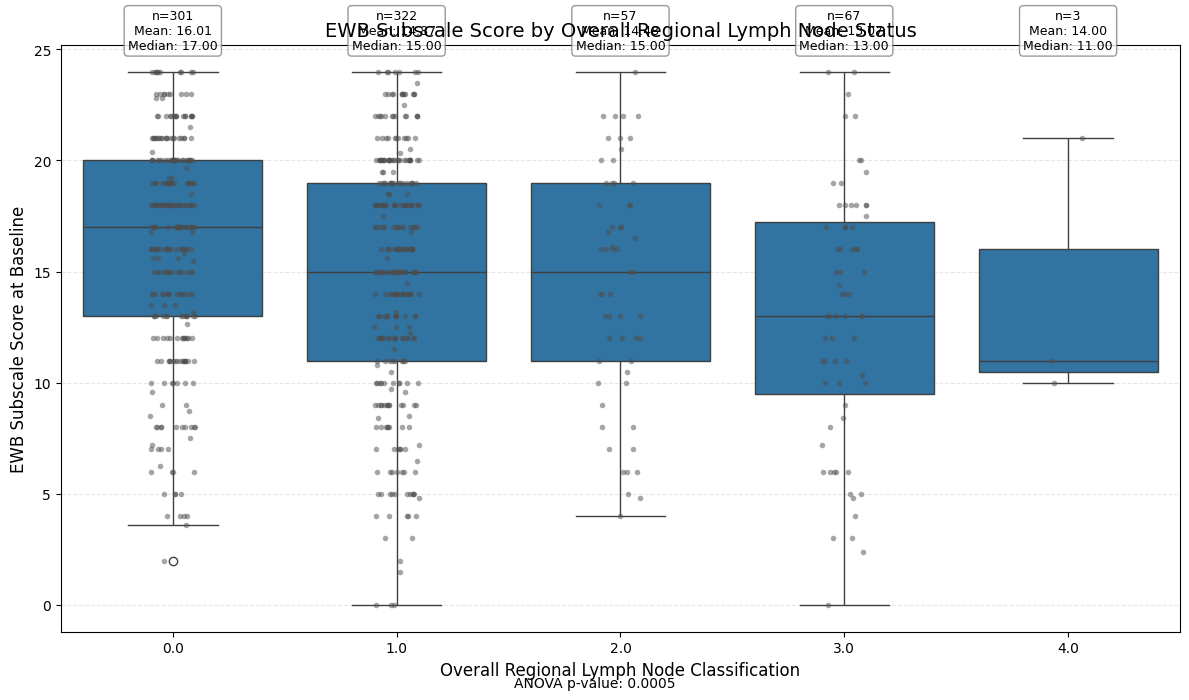

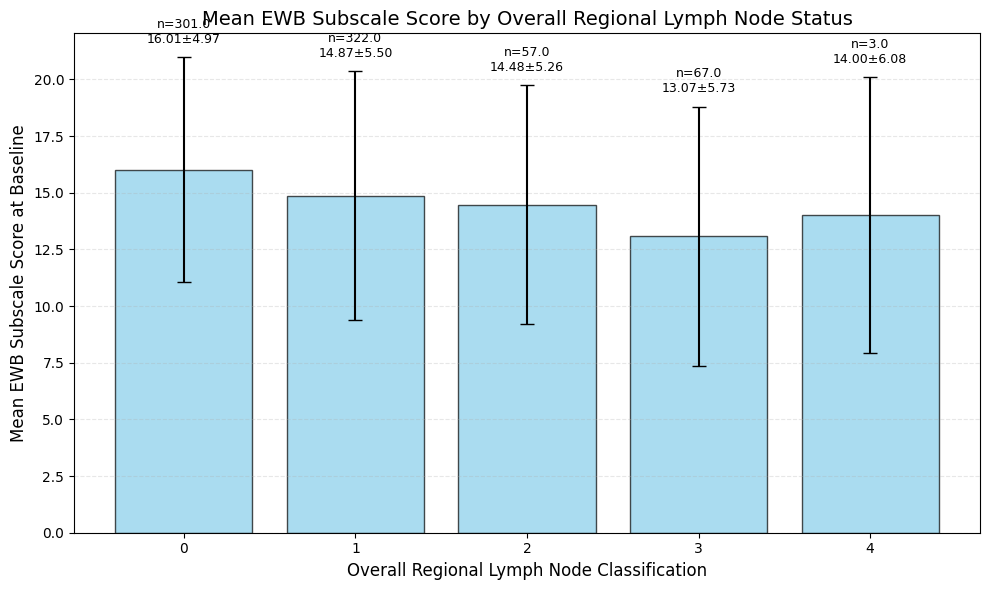

In [32]:

df = merged_df_removedNA_ln.copy()

# Create a boxplot to compare distributions across different node classifications
plt.figure(figsize=(12, 7))

# Create box plot
sns.boxplot(x='overall_regional_ln', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='overall_regional_ln', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.5, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Overall Regional Lymph Node Status', fontsize=14)
plt.xlabel('Overall Regional Lymph Node Classification', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display summary statistics for each classification
node_classes = sorted(df['overall_regional_ln'].unique())
for i, node_class in enumerate(node_classes):
    subset = df[df['overall_regional_ln'] == node_class]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform statistical test (ANOVA) if there are more than 2 groups
if len(node_classes) > 2:
    groups = [df[df['overall_regional_ln'] == n]['ewb_subscale_score_baseline'].dropna() for n in node_classes]
    groups = [g for g in groups if len(g) > 0]  # Remove empty groups
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        plt.figtext(0.5, 0.01, f'ANOVA p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()

# Create a bar chart showing mean EWB scores by lymph node status
plt.figure(figsize=(10, 6))

# Calculate mean EWB score for each lymph node classification
mean_scores = df.groupby('overall_regional_ln')['ewb_subscale_score_baseline'].mean().reset_index()
std_scores = df.groupby('overall_regional_ln')['ewb_subscale_score_baseline'].std().reset_index()
count_scores = df.groupby('overall_regional_ln').size().reset_index(name='count')

# Merge data
plot_data = pd.merge(mean_scores, std_scores, on='overall_regional_ln', suffixes=('_mean', '_std'))
plot_data = pd.merge(plot_data, count_scores, on='overall_regional_ln')

# Create bar chart with error bars
plt.bar(plot_data['overall_regional_ln'], plot_data['ewb_subscale_score_baseline_mean'], 
        yerr=plot_data['ewb_subscale_score_baseline_std'], capsize=5, 
        color='skyblue', edgecolor='black', alpha=0.7)

# Add data labels
for i, row in plot_data.iterrows():
    plt.text(row['overall_regional_ln'], row['ewb_subscale_score_baseline_mean'] + row['ewb_subscale_score_baseline_std'] + 0.5, 
             f'n={row["count"]}\n{row["ewb_subscale_score_baseline_mean"]:.2f}±{row["ewb_subscale_score_baseline_std"]:.2f}', 
             ha='center', va='bottom', fontsize=9)

plt.title('Mean EWB Subscale Score by Overall Regional Lymph Node Status', fontsize=14)
plt.xlabel('Overall Regional Lymph Node Classification', fontsize=12)
plt.ylabel('Mean EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.xticks(node_classes)
plt.tight_layout()

plt.show()

# statistically significantly associated with 8) clinical staging (overall_distant_metastasis)

In [33]:
# Merge score_comparison with overall_distant_metastasis data
merged_df_M = score_comparison.merge(df_extracted[["id", "overall_distant_metastasis"]], on="id", how="left")

# Remove rows where overall_distant_metastasis is missing
merged_df_removedNA_M = merged_df_M.dropna(subset=["overall_distant_metastasis"])
merged_df_expanded_M = merged_df_removedNA_M.drop_duplicates()
merged_df_removedNA_M = merged_df_expanded_M.copy()
merged_df_removedNA_M

,id,baseline_type,ewb_subscale_score_baseline,overall_distant_metastasis
5,2,baseline_arm_1,14.0,0.0
10,3,baseline_arm_1,14.0,0.0
19,4,baseline_arm_1,23.0,2.0
22,7,baseline_arm_1,5.0,2.0
30,8,baseline_arm_1,18.0,2.0
...,...,...,...,...
6070,1756,baseline_arm_1,19.0,0.0
6076,1759,baseline_arm_1,18.0,1.0
6088,1763,baseline_arm_1,14.0,0.0
6090,1765,baseline_arm_1,15.0,0.0


In [34]:
regional_M_mapping = {
    0: 0,
    1: 1,
    2: None
}

# Apply mapping to convert ln stage to numeric
merged_df_removedNA_M["overall_distant_metastasis"] = merged_df_removedNA_M["overall_distant_metastasis"].map(regional_M_mapping)

# Remove any NaN values after mapping
merged_df_removedNA_M = merged_df_removedNA_M.dropna(subset=["overall_distant_metastasis"])
merged_df_removedNA_M

,id,baseline_type,ewb_subscale_score_baseline,overall_distant_metastasis
5,2,baseline_arm_1,14.0,0.0
10,3,baseline_arm_1,14.0,0.0
39,9,baseline_arm_1,20.0,1.0
68,19,baseline_arm_1,14.0,1.0
73,20,baseline_arm_1,16.0,0.0
...,...,...,...,...
6070,1756,baseline_arm_1,19.0,0.0
6076,1759,baseline_arm_1,18.0,1.0
6088,1763,baseline_arm_1,14.0,0.0
6090,1765,baseline_arm_1,15.0,0.0


In [36]:

def analyze_ewb_metastasis_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and distant metastasis status
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Statistical Test Results)
    """
    df = data_path.copy()

    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['overall_distant_metastasis'] = pd.to_numeric(df['overall_distant_metastasis'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'overall_distant_metastasis'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Add metastasis labels for clarity
    df_clean['metastasis_label'] = df_clean['overall_distant_metastasis'].map({0.0: 'No Metastasis', 1.0: 'Metastasis Present'})
    
    # Basic descriptive statistics by metastasis status
    print("\n--- Descriptive Statistics by Metastasis Status ---")
    stats_by_metastasis = df_clean.groupby('metastasis_label')['ewb_subscale_score_baseline'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats_by_metastasis)
    
    # Separate the data by metastasis status
    no_metastasis = df_clean[df_clean['overall_distant_metastasis'] == 0.0]['ewb_subscale_score_baseline']
    metastasis = df_clean[df_clean['overall_distant_metastasis'] == 1.0]['ewb_subscale_score_baseline']
    
    # Independent t-test
    if len(no_metastasis) > 1 and len(metastasis) > 1:
        t_stat, p_value = stats.ttest_ind(
            no_metastasis,
            metastasis,
            equal_var=False  # Using Welch's t-test which doesn't assume equal variances
        )
        
        print("\n--- Independent Samples T-Test ---")
        print(f"t-statistic: {t_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
        
        # Calculate effect size (Cohen's d)
        no_metastasis_mean = no_metastasis.mean()
        metastasis_mean = metastasis.mean()
        no_metastasis_std = no_metastasis.std()
        metastasis_std = metastasis.std()
        
        # Pooled standard deviation
        n1, n2 = len(no_metastasis), len(metastasis)
        pooled_std = np.sqrt(((n1 - 1) * no_metastasis_std**2 + (n2 - 1) * metastasis_std**2) / (n1 + n2 - 2))
        
        # Cohen's d
        cohens_d = abs(no_metastasis_mean - metastasis_mean) / pooled_std
        
        print(f"Effect size (Cohen's d): {cohens_d:.4f}")
        
        if cohens_d < 0.2:
            effect_size_interp = "negligible"
        elif cohens_d < 0.5:
            effect_size_interp = "small"
        elif cohens_d < 0.8:
            effect_size_interp = "medium"
        else:
            effect_size_interp = "large"
        
        print(f"Effect size interpretation: {effect_size_interp}")
    else:
        print("\nCannot perform t-test: Need at least 2 samples in each metastasis group")
    
    # Mann-Whitney U test (non-parametric alternative)
    if len(no_metastasis) > 0 and len(metastasis) > 0:
        u_stat, p_value_mw = stats.mannwhitneyu(
            no_metastasis,
            metastasis,
            alternative='two-sided'
        )
        
        print("\n--- Mann-Whitney U Test ---")
        print(f"U-statistic: {u_stat:.4f}")
        print(f"p-value: {p_value_mw:.4f}")
        print(f"Statistically significant: {'Yes' if p_value_mw < 0.05 else 'No'}")
    else:
        print("\nCannot perform Mann-Whitney U test: Need at least 1 sample in each metastasis group")
    
    # Logistic regression (predicting metastasis from EWB score)
    # This provides a different perspective on the relationship
    print("\n--- Logistic Regression Analysis ---")
    print("(Predicting metastasis status from EWB score)")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['ewb_subscale_score_baseline'])
    y = df_clean['overall_distant_metastasis']
    
    # Fit logistic regression model
    try:
        model = sm.Logit(y, X)
        results = model.fit(disp=0)  # disp=0 suppresses convergence messages
        
        print(results.summary())
        
        # Extract odds ratio and confidence intervals
        params = results.params
        conf = results.conf_int()
        conf['OR'] = params
        conf.columns = ['2.5%', '97.5%', 'OR']
        conf['OR'] = np.exp(conf['OR'])
        conf['2.5%'] = np.exp(conf['2.5%'])
        conf['97.5%'] = np.exp(conf['97.5%'])
        
        print("\n--- Odds Ratios ---")
        print(conf)
        
        # Interpreting the results
        ewb_coef = results.params['ewb_subscale_score_baseline']
        ewb_pvalue = results.pvalues['ewb_subscale_score_baseline']
        ewb_or = np.exp(ewb_coef)
        
        print("\n--- Interpretation ---")
        if ewb_pvalue < 0.05:
            print(f"EWB score is significantly associated with metastasis status (p={ewb_pvalue:.4f})")
            if ewb_coef > 0:
                print(f"Higher EWB scores are associated with INCREASED odds of distant metastasis")
                print(f"For each 1-point increase in EWB score, the odds of metastasis increase by {(ewb_or-1)*100:.1f}%")
            else:
                print(f"Higher EWB scores are associated with DECREASED odds of distant metastasis")
                print(f"For each 1-point increase in EWB score, the odds of metastasis decrease by {(1-ewb_or)*100:.1f}%")
        else:
            print(f"EWB score is NOT significantly associated with metastasis status (p={ewb_pvalue:.4f})")
    except:
        print("Could not perform logistic regression - possible issues with model convergence or separation")
        print("This often occurs with small sample sizes or when there is complete separation in the data")
    
    # Linear regression (predicting EWB score from metastasis status)
    print("\n--- Linear Regression Analysis ---")
    print("(Predicting EWB score from metastasis status)")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['overall_distant_metastasis'])
    y = df_clean['ewb_subscale_score_baseline']
    
    # Fit linear regression model
    model_linear = sm.OLS(y, X)
    results_linear = model_linear.fit()
    
    print(results_linear.summary())
    
    # Interpretation of linear regression
    metastasis_coef = results_linear.params['overall_distant_metastasis']
    metastasis_pvalue = results_linear.pvalues['overall_distant_metastasis']
    intercept = results_linear.params['const']
    
    print("\n--- Simplified Linear Model ---")
    print(f"EWB score = {intercept:.2f} + {metastasis_coef:.2f} × Metastasis Status")
    print(f"Mean EWB score for patients without metastasis: {intercept:.2f}")
    print(f"Mean EWB score for patients with metastasis: {intercept + metastasis_coef:.2f}")
    print(f"Difference: {metastasis_coef:.2f}")
    print(f"p-value: {metastasis_pvalue:.4f}")
    print(f"Statistically significant: {'Yes' if metastasis_pvalue < 0.05 else 'No'}")
    
    # Final summarized interpretation
    print("\n--- Overall Interpretation ---")
    
    if p_value < 0.05 or metastasis_pvalue < 0.05:
        higher_group = "with" if metastasis_mean > no_metastasis_mean else "without"
        print(f"There is a statistically significant difference in EWB scores between patients with and without distant metastasis")
        print(f"On average, patients {higher_group} distant metastasis have higher EWB scores.")
        print(f"The difference is approximately {abs(metastasis_mean - no_metastasis_mean):.2f} points.")
    else:
        print(f"There is NO statistically significant difference in EWB scores between patients with and without distant metastasis")
        print(f"Although patients with metastasis had a mean score of {metastasis_mean:.2f} compared to {no_metastasis_mean:.2f} for those without,")
        print(f"this difference of {abs(metastasis_mean - no_metastasis_mean):.2f} points was not statistically significant (p={p_value:.4f}).")
    
    # Additional clinical interpretation
    print("\n--- Clinical Relevance ---")
    print("Note: A difference of 2-3 points in the FACT-G EWB subscale is often considered")
    print("clinically meaningful. The statistical significance and the magnitude of the")
    print("difference should both be considered when interpreting these results.")
    
    return df_clean, (t_stat, p_value) if len(no_metastasis) > 1 and len(metastasis) > 1 else None

# If you have your own data:
df, test_results = analyze_ewb_metastasis_association(merged_df_removedNA_M)

Analysis based on 708 complete cases

--- Descriptive Statistics by Metastasis Status ---
                    count       mean       std  min  median   max
metastasis_label                                                 
Metastasis Present    118  13.744068  5.678623  0.0    14.0  24.0
No Metastasis         590  15.333870  5.270549  0.0    16.0  24.0

--- Independent Samples T-Test ---
t-statistic: 2.8088
p-value: 0.0056
Statistically significant: Yes
Effect size (Cohen's d): 0.2977
Effect size interpretation: small

--- Mann-Whitney U Test ---
U-statistic: 40334.0000
p-value: 0.0064
Statistically significant: Yes

--- Logistic Regression Analysis ---
(Predicting metastasis status from EWB score)
                               Logit Regression Results                               
Dep. Variable:     overall_distant_metastasis   No. Observations:                  708
Model:                                  Logit   Df Residuals:                      706
Method:                         

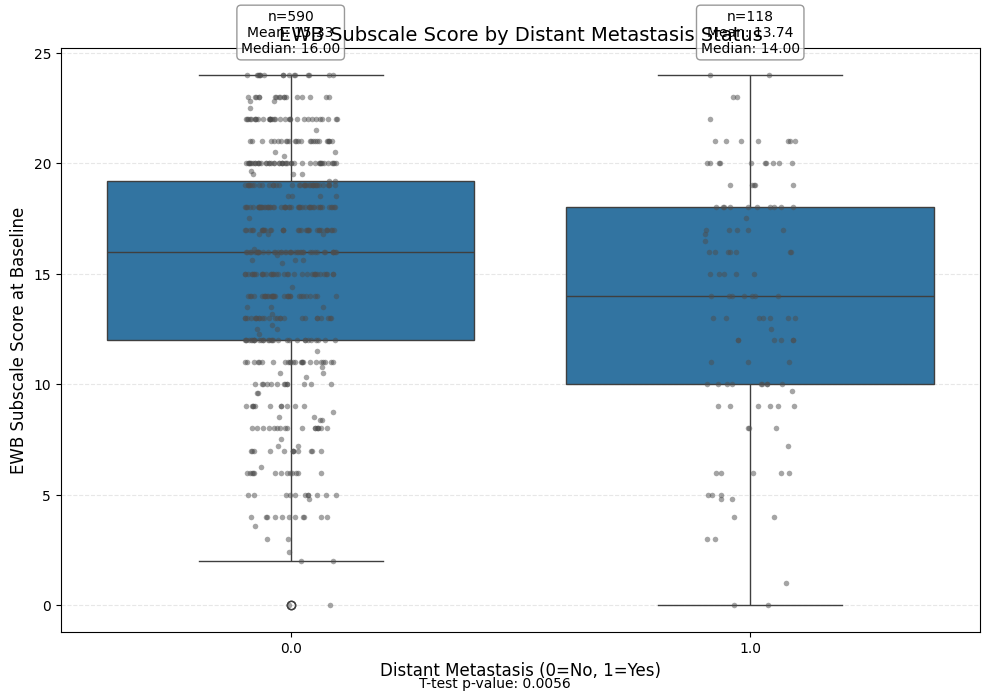

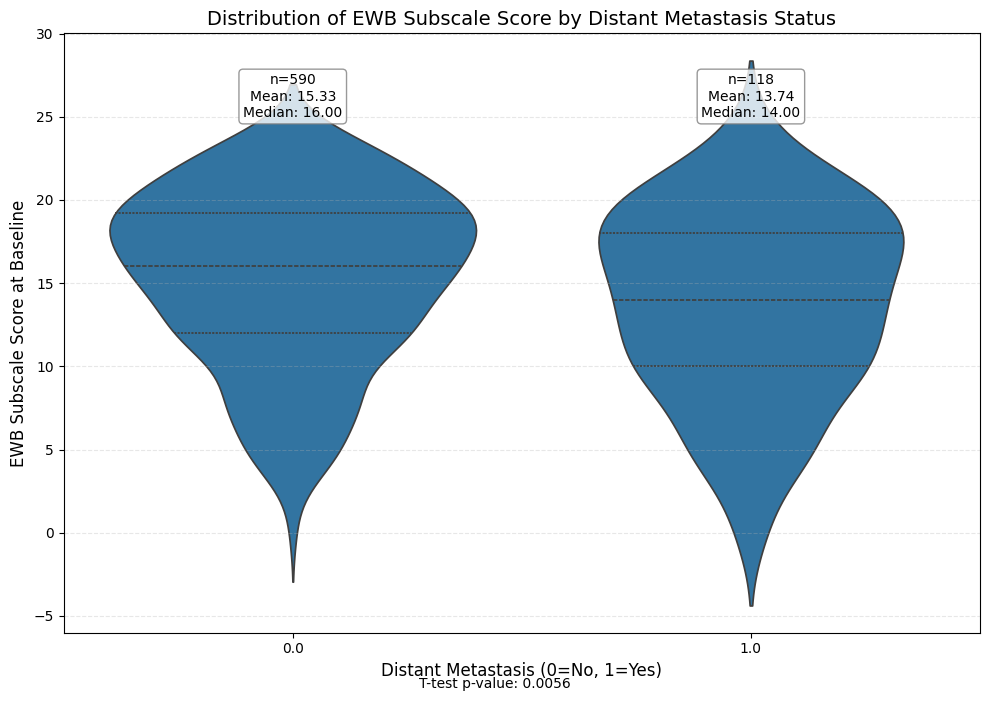

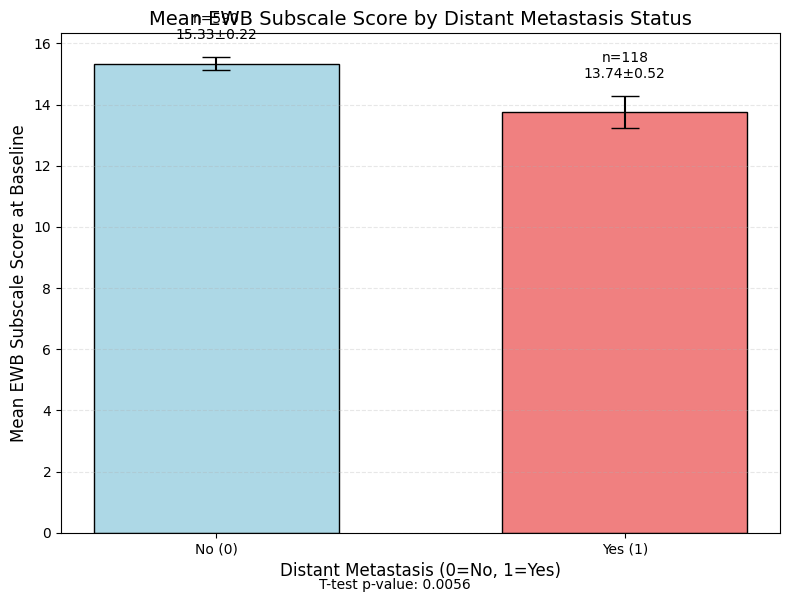

In [37]:

df = merged_df_removedNA_M.copy()

# Since overall_distant_metastasis is binary (0 vs 1), we can use a box plot
plt.figure(figsize=(10, 7))

# Create box plot
sns.boxplot(x='overall_distant_metastasis', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='overall_distant_metastasis', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.5, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Distant Metastasis Status', fontsize=14)
plt.xlabel('Distant Metastasis (0=No, 1=Yes)', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display summary statistics
metastasis_values = [0, 1]
for i, met_status in enumerate(metastasis_values):
    subset = df[df['overall_distant_metastasis'] == met_status]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform t-test to compare the two groups
met_0 = df[df['overall_distant_metastasis'] == 0]['ewb_subscale_score_baseline'].dropna()
met_1 = df[df['overall_distant_metastasis'] == 1]['ewb_subscale_score_baseline'].dropna()
if len(met_0) > 0 and len(met_1) > 0:
    stat, p_value = stats.ttest_ind(met_0, met_1, equal_var=False)
    plt.figtext(0.5, 0.01, f'T-test p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()

# Create a violin plot to better visualize the distributions
plt.figure(figsize=(10, 7))
sns.violinplot(x='overall_distant_metastasis', y='ewb_subscale_score_baseline', data=df, inner='quartile')

plt.title('Distribution of EWB Subscale Score by Distant Metastasis Status', fontsize=14)
plt.xlabel('Distant Metastasis (0=No, 1=Yes)', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add the same statistics
for i, met_status in enumerate(metastasis_values):
    subset = df[df['overall_distant_metastasis'] == met_status]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.figtext(0.5, 0.01, f'T-test p-value: {p_value:.4f}', ha='center', fontsize=10)
plt.tight_layout()

# Create a bar chart comparing the means with error bars
plt.figure(figsize=(8, 6))

# Calculate means and standard errors
means = df.groupby('overall_distant_metastasis')['ewb_subscale_score_baseline'].mean()
stderrs = df.groupby('overall_distant_metastasis')['ewb_subscale_score_baseline'].sem()
counts = df.groupby('overall_distant_metastasis').size()

# Create the bar chart
bars = plt.bar([0, 1], means, yerr=stderrs, capsize=10, color=['lightblue', 'lightcoral'], 
        edgecolor='black', width=0.6)

# Add data labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + stderrs[i] + 0.5,
            f'n={counts[i]}\n{means[i]:.2f}±{stderrs[i]:.2f}',
            ha='center', va='bottom', fontsize=10)

plt.title('Mean EWB Subscale Score by Distant Metastasis Status', fontsize=14)
plt.xlabel('Distant Metastasis (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Mean EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.figtext(0.5, 0.01, f'T-test p-value: {p_value:.4f}', ha='center', fontsize=10)
plt.tight_layout()

plt.show()

# statistically significantly associated with 9) Neoadjuvant treatment (six neotx)

In [49]:

def fix_violations_when_notx_is_one(df):
    """
    1. Identify rows where neotx__notx = 1 and other neotx columns have values other than 0 or NaN
    2. Replace neotx__notx with 0 for those violation rows
    
    Parameters:
    df (DataFrame): The pandas DataFrame with all neotx columns
    
    Returns:
    tuple: (modified_df, violation_info)
        - modified_df: DataFrame with fixes applied
        - violation_info: Dict with information about what was changed
    """
    # Create a copy of the DataFrame to avoid modifying the original
    modified_df = df.copy()
    
    # Get all neotx columns except neotx__notx
    other_columns = [col for col in df.columns if col.startswith('neotx__') and col != 'neotx___notx']
    
    # Select rows where neotx__notx is 1
    notx_is_one = df[df['neotx___notx'] == 1].copy()
    
    if len(notx_is_one) == 0:
        return modified_df, {"status": "No rows found where neotx___notx = 1"}
    
    # Find rows with violations
    violation_rows = set()
    column_violations = {}
    
    for col in other_columns:
        # Find rows where column is not NaN and not 0
        invalid_mask = ~(notx_is_one[col].isna() | (notx_is_one[col] == 0))
        invalid_rows = notx_is_one[invalid_mask]
        
        if len(invalid_rows) > 0:
            violation_rows.update(invalid_rows.index.tolist())
            column_violations[col] = len(invalid_rows)
    
    # Convert violation_rows to a list for indexing
    violation_indices = list(violation_rows)
    
    # Store original values for reporting
    original_values = {}
    if 'id' in df.columns:
        original_values = {
            'indices': violation_indices,
            'ids': df.loc[violation_indices, 'id'].tolist() if 'id' in df.columns else []
        }
    
    # Apply the fix - set neotx__notx to 0 for violation rows
    if violation_indices:
        modified_df.loc[violation_indices, 'neotx___notx'] = 0
    
    # Create a report
    violation_info = {
        'total_rows_with_notx_1': len(notx_is_one),
        'total_violations_fixed': len(violation_indices),
        'violation_details': column_violations,
        'original_values': original_values
    }
    
    return modified_df, violation_info

# Example usage:
fixed_df, report = fix_violations_when_notx_is_one(df_extracted)

print(f"Total rows where neotx___notx was 1: {report['total_rows_with_notx_1']}")
print(f"Number of rows fixed: {report['total_violations_fixed']}")

if report['total_violations_fixed'] > 0:
    print("\nViolations found by column:")
    for col, count in report['violation_details'].items():
        print(f"  - {col}: {count} violations")
    
    if 'ids' in report['original_values'] and report['original_values']['ids']:
        print(f"\nIDs of fixed rows: {report['original_values']['ids']}")
    else:
        print(f"\nIndices of fixed rows: {report['original_values']['indices']}")
    
    print("\nAll these rows had neotx___notx changed from 1 to 0")


Total rows where neotx___notx was 1: 364
Number of rows fixed: 5

Violations found by column:
  - neotx___rads: 1 violations
  - neotx___other: 4 violations

IDs of fixed rows: [1069, 250, 879, 1202, 1016]

All these rows had neotx___notx changed from 1 to 0


In [ ]:


def check_violations_by_id_when_notx_is_one(df):
    """
    Check for violations when neotx___notx = 1, identifying rows by their ID column.
    Violations occur when other neotx columns have values that are not 0 or NaN.
    
    Parameters:
    df (DataFrame): The pandas DataFrame with an 'id' column
    
    Returns:
    dict: Information about violations identified by ID
    """
    # Ensure 'id' column exists
    if 'id' not in df.columns:
        return {"error": "DataFrame does not contain an 'id' column"}
    
    # Get all neotx columns except neotx___notx
    other_columns = [col for col in df.columns if col.startswith('neotx__') and col != 'neotx___notx']
    
    # Select rows where neotx___notx is 1
    notx_is_one = df[df['neotx___notx'] == 1].copy()
    
    if len(notx_is_one) == 0:
        return {"status": "No rows found where neotx___notx = 1"}
    
    # Identify violations (non-NaN and non-zero values in other columns)
    violations = {}
    all_violation_ids = set()
    
    for col in other_columns:
        # Find rows where column is not NaN and not 0
        invalid_mask = ~(notx_is_one[col].isna() | (notx_is_one[col] == 0))
        invalid_rows = notx_is_one[invalid_mask]
        
        if len(invalid_rows) > 0:
            # Store IDs and values of violations
            violations[col] = {
                "count": len(invalid_rows),
                "ids": invalid_rows['id'].tolist(),
                "values": invalid_rows[col].tolist()
            }
            all_violation_ids.update(invalid_rows['id'].tolist())
    
    # Create a detailed report
    result = {
        "total_rows_with_notx_1": len(notx_is_one),
        "total_violation_rows": len(all_violation_ids),
        "violation_ids": sorted(list(all_violation_ids)),
        "detailed_violations": violations
    }
    
    # To give a sample of the actual data with violations
    if all_violation_ids:
        sample_ids = sorted(list(all_violation_ids))[:10]  # First 10 violation IDs
        sample_data = df[df['id'].isin(sample_ids)][['id', 'neotx___notx'] + other_columns]
        result["sample_violation_data"] = sample_data.to_dict('records')
    
    return result

# Example usage:
violations = check_violations_by_id_when_notx_is_one(fixed_df)

print(f"Total rows where neotx___notx = 1: {violations['total_rows_with_notx_1']}")
print(f"Number of rows with violations: {violations['total_violation_rows']}")

if violations['total_violation_rows'] > 0:
    print(f"\nIDs of rows with violations: {violations['violation_ids']}")
    
    print("\nViolation details by column:")
    for col, details in violations['detailed_violations'].items():
        print(f"\n{col}:")
        print(f"  - {details['count']} violations")
        print(f"  - First 5 violation IDs: {details['ids'][:5]}")
        print(f"  - First 5 values: {details['values'][:5]}")
    
    print("\nSample of violation rows:")
    for row_data in violations["sample_violation_data"]:
        print(f"\nViolation for ID {row_data['id']}:")
        for col, val in row_data.items():
            if col != 'id':
                print(f"  {col}: {val}")

Total rows where neotx___notx = 1: 359
Number of rows with violations: 0


In [68]:

def create_neotx___binary_column(df):
    """
    Create a new binary column 'neotx___binary' where:
    - If neotx__notx == 1, then neotx___binary = 0
    - If all neotx columns are NaN, then neotx___binary = NaN
    - Otherwise, neotx___binary = 1
    
    Parameters:
    df (DataFrame): The pandas DataFrame with neotx columns
    
    Returns:
    DataFrame: The DataFrame with the new binary column added
    """
    # Create a copy of the DataFrame to avoid modifying the original
    modified_df = df.copy()
    
    # Define all neotx columns
    neotx_columns = ["neotx___notx", "neotx___chemo", "neotx___rads", 
                    "neotx___chemorads", "neotx___immuno", "neotx___other"]
    
    # Verify columns exist
    for col in neotx_columns:
        if col not in modified_df.columns:
            raise KeyError(f"Column '{col}' not found in the DataFrame")
    
    # Create a mask for rows where all neotx columns are NaN
    all_nan_mask = modified_df[neotx_columns].isna().all(axis=1)
    
    # Create the new binary column initialized with NaN
    modified_df['neotx___binary'] = np.nan
    
    # Where neotx___notx is 1, neotx___binary will be 0
    modified_df.loc[modified_df['neotx___notx'] == 1, 'neotx___binary'] = 0
    
    # Where any neotx column has a value and neotx___notx is not 1, neotx___binary will be 1
    non_nan_mask = ~all_nan_mask
    not_notx_mask = (modified_df['neotx___notx'] != 1) | modified_df['neotx___notx'].isna()
    modified_df.loc[non_nan_mask & not_notx_mask, 'neotx___binary'] = 1
    
    # Count how many rows got each value
    zeros_count = (modified_df['neotx___binary'] == 0).sum()
    ones_count = (modified_df['neotx___binary'] == 1).sum()
    nans_count = modified_df['neotx___binary'].isna().sum()
    
    info = {
        'total_rows': len(modified_df),
        'rows_with_neotx___binary_0': zeros_count,
        'rows_with_neotx___binary_1': ones_count,
        'rows_with_neotx___binary_NaN': nans_count
    }
    
    return modified_df, info

# Example usage:
df_with_binary, info = create_neotx___binary_column(fixed_df)

print(f"New column 'neotx___binary' created with:")
print(f"- {info['rows_with_neotx___binary_0']} rows with value 0 (neotx___notx was 1)")
print(f"- {info['rows_with_neotx___binary_1']} rows with value 1 (neotx___notx was not 1, at least one neotx column had a value)")
print(f"- {info['rows_with_neotx___binary_NaN']} rows with value NaN (all neotx columns were NaN)")

New column 'neotx___binary' created with:
- 359 rows with value 0 (neotx___notx was 1)
- 1214 rows with value 1 (neotx___notx was not 1, at least one neotx column had a value)
- 8526 rows with value NaN (all neotx columns were NaN)


In [67]:
df_with_binary

,id,operation_date,redcap_event_name,dob,qol_date,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,...,ge2,ge3,ge4,ge5,ge6,readmission_30d,postop_comp,los,DischargeDate,neotx___binary
0,1,NaT,baseline_arm_1,1949-08-04,NaT,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27,NaN
1,1,2011-08-26,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26,NaN
2,1,2010-02-20,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08,NaN
3,1,2009-05-27,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27,NaN
4,1,2009-02-25,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10094,1766,NaT,baseline_arm_1,NaT,NaT,62.845917,NaN,1b,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
10095,1766,2025-02-26,surgery_arm_1,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
10096,1767,NaT,baseline_arm_1,1971-12-18,NaT,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
10097,1767,NaT,baseline_arm_1,NaT,2025-03-03,NaN,NaN,NaN,NaN,NaN,...,2.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN,NaT,NaN


In [69]:
merged_df_neo = score_comparison.merge(df_with_binary[["id", "neotx___binary"]], on="id", how="left")

# Remove rows where neo is missing
merged_df_removedNA_neo = merged_df_neo.dropna(subset=["neotx___binary"])
merged_df_expanded_neo = merged_df_removedNA_neo.drop_duplicates()
merged_df_removedNA_neo = merged_df_expanded_neo.copy()
merged_df_removedNA_neo

,id,baseline_type,ewb_subscale_score_baseline,neotx___binary
17,4,baseline_arm_1,23.0,0.0
23,7,baseline_arm_1,5.0,1.0
32,8,baseline_arm_1,18.0,1.0
36,9,baseline_arm_1,20.0,0.0
46,12,baseline_arm_1,14.0,1.0
...,...,...,...,...
6047,1745,baseline_arm_1,14.0,1.0
6052,1747,baseline_arm_1,23.0,1.0
6056,1748,baseline_arm_1,9.0,1.0
6084,1762,baseline_arm_1,21.0,1.0


In [70]:

def analyze_ewb_neotx_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and neoadjuvant therapy status
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Statistical Test Results)
    """
    df = data_path.copy()
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['neotx___binary'] = pd.to_numeric(df['neotx___binary'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'neotx___binary'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Add therapy labels for clarity
    df_clean['neotx_label'] = df_clean['neotx___binary'].map({0.0: 'No Neoadjuvant Therapy', 1.0: 'Received Neoadjuvant Therapy'})
    
    # Basic descriptive statistics by therapy status
    print("\n--- Descriptive Statistics by Neoadjuvant Therapy Status ---")
    stats_by_neotx = df_clean.groupby('neotx_label')['ewb_subscale_score_baseline'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats_by_neotx)
    
    # Separate the data by therapy status
    no_neotx = df_clean[df_clean['neotx___binary'] == 0.0]['ewb_subscale_score_baseline']
    neotx = df_clean[df_clean['neotx___binary'] == 1.0]['ewb_subscale_score_baseline']
    
    # Independent t-test
    if len(no_neotx) > 1 and len(neotx) > 1:
        t_stat, p_value = stats.ttest_ind(
            no_neotx,
            neotx,
            equal_var=False  # Using Welch's t-test which doesn't assume equal variances
        )
        
        print("\n--- Independent Samples T-Test ---")
        print(f"t-statistic: {t_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
        
        # Calculate effect size (Cohen's d)
        no_neotx_mean = no_neotx.mean()
        neotx_mean = neotx.mean()
        no_neotx_std = no_neotx.std()
        neotx_std = neotx.std()
        
        # Pooled standard deviation
        n1, n2 = len(no_neotx), len(neotx)
        pooled_std = np.sqrt(((n1 - 1) * no_neotx_std**2 + (n2 - 1) * neotx_std**2) / (n1 + n2 - 2))
        
        # Cohen's d
        cohens_d = abs(no_neotx_mean - neotx_mean) / pooled_std
        
        print(f"Effect size (Cohen's d): {cohens_d:.4f}")
        
        if cohens_d < 0.2:
            effect_size_interp = "negligible"
        elif cohens_d < 0.5:
            effect_size_interp = "small"
        elif cohens_d < 0.8:
            effect_size_interp = "medium"
        else:
            effect_size_interp = "large"
        
        print(f"Effect size interpretation: {effect_size_interp}")
    else:
        print("\nCannot perform t-test: Need at least 2 samples in each therapy group")
    
    # Mann-Whitney U test (non-parametric alternative)
    if len(no_neotx) > 0 and len(neotx) > 0:
        u_stat, p_value_mw = stats.mannwhitneyu(
            no_neotx,
            neotx,
            alternative='two-sided'
        )
        
        print("\n--- Mann-Whitney U Test ---")
        print(f"U-statistic: {u_stat:.4f}")
        print(f"p-value: {p_value_mw:.4f}")
        print(f"Statistically significant: {'Yes' if p_value_mw < 0.05 else 'No'}")
    else:
        print("\nCannot perform Mann-Whitney U test: Need at least 1 sample in each therapy group")
    
    # Logistic regression (predicting therapy status from EWB score)
    # This provides a different perspective on the relationship
    print("\n--- Logistic Regression Analysis ---")
    print("(Predicting neoadjuvant therapy status from EWB score)")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['ewb_subscale_score_baseline'])
    y = df_clean['neotx___binary']
    
    # Fit logistic regression model
    try:
        model = sm.Logit(y, X)
        results = model.fit(disp=0)  # disp=0 suppresses convergence messages
        
        print(results.summary())
        
        # Extract odds ratio and confidence intervals
        params = results.params
        conf = results.conf_int()
        conf['OR'] = params
        conf.columns = ['2.5%', '97.5%', 'OR']
        conf['OR'] = np.exp(conf['OR'])
        conf['2.5%'] = np.exp(conf['2.5%'])
        conf['97.5%'] = np.exp(conf['97.5%'])
        
        print("\n--- Odds Ratios ---")
        print(conf)
        
        # Interpreting the results
        ewb_coef = results.params['ewb_subscale_score_baseline']
        ewb_pvalue = results.pvalues['ewb_subscale_score_baseline']
        ewb_or = np.exp(ewb_coef)
        
        print("\n--- Interpretation ---")
        if ewb_pvalue < 0.05:
            print(f"EWB score is significantly associated with neoadjuvant therapy status (p={ewb_pvalue:.4f})")
            if ewb_coef > 0:
                print(f"Higher EWB scores are associated with INCREASED odds of receiving neoadjuvant therapy")
                print(f"For each 1-point increase in EWB score, the odds of receiving neoadjuvant therapy increase by {(ewb_or-1)*100:.1f}%")
            else:
                print(f"Higher EWB scores are associated with DECREASED odds of receiving neoadjuvant therapy")
                print(f"For each 1-point increase in EWB score, the odds of receiving neoadjuvant therapy decrease by {(1-ewb_or)*100:.1f}%")
        else:
            print(f"EWB score is NOT significantly associated with neoadjuvant therapy status (p={ewb_pvalue:.4f})")
    except:
        print("Could not perform logistic regression - possible issues with model convergence or separation")
        print("This often occurs with small sample sizes or when there is complete separation in the data")
    
    # Linear regression (predicting EWB score from therapy status)
    print("\n--- Linear Regression Analysis ---")
    print("(Predicting EWB score from neoadjuvant therapy status)")
    
    # Add constant for intercept
    X = sm.add_constant(df_clean['neotx___binary'])
    y = df_clean['ewb_subscale_score_baseline']
    
    # Fit linear regression model
    model_linear = sm.OLS(y, X)
    results_linear = model_linear.fit()
    
    print(results_linear.summary())
    
    # Interpretation of linear regression
    neotx_coef = results_linear.params['neotx___binary']
    neotx_pvalue = results_linear.pvalues['neotx___binary']
    intercept = results_linear.params['const']
    
    print("\n--- Simplified Linear Model ---")
    print(f"EWB score = {intercept:.2f} + {neotx_coef:.2f} × Neoadjuvant Therapy Status")
    print(f"Mean EWB score for patients without neoadjuvant therapy: {intercept:.2f}")
    print(f"Mean EWB score for patients with neoadjuvant therapy: {intercept + neotx_coef:.2f}")
    print(f"Difference: {neotx_coef:.2f}")
    print(f"p-value: {neotx_pvalue:.4f}")
    print(f"Statistically significant: {'Yes' if neotx_pvalue < 0.05 else 'No'}")
    
    # Final summarized interpretation
    print("\n--- Overall Interpretation ---")
    
    if p_value < 0.05 or neotx_pvalue < 0.05:
        higher_group = "with" if neotx_mean > no_neotx_mean else "without"
        print(f"There is a statistically significant difference in EWB scores between patients who did and did not receive neoadjuvant therapy")
        print(f"On average, patients {higher_group} neoadjuvant therapy have higher EWB scores.")
        print(f"The difference is approximately {abs(neotx_mean - no_neotx_mean):.2f} points.")
    else:
        print(f"There is NO statistically significant difference in EWB scores between patients who did and did not receive neoadjuvant therapy")
        print(f"Although patients with neoadjuvant therapy had a mean score of {neotx_mean:.2f} compared to {no_neotx_mean:.2f} for those without,")
        print(f"this difference of {abs(neotx_mean - no_neotx_mean):.2f} points was not statistically significant (p={p_value:.4f}).")
    
    # Additional clinical interpretation
    print("\n--- Clinical Relevance ---")
    print("Note: A difference of 2-3 points in the FACT-G EWB subscale is often considered")
    print("clinically meaningful. The statistical significance and the magnitude of the")
    print("difference should both be considered when interpreting these results.")
    
    return df_clean, (t_stat, p_value) if len(no_neotx) > 1 and len(neotx) > 1 else None

df, test_results = analyze_ewb_neotx_association(merged_df_removedNA_neo)

Analysis based on 837 complete cases

--- Descriptive Statistics by Neoadjuvant Therapy Status ---
                              count       mean       std  min  median   max
neotx_label                                                                
No Neoadjuvant Therapy          171  16.256725  5.026553  1.5    17.0  24.0
Received Neoadjuvant Therapy    666  15.023999  5.406461  0.0    16.0  24.0

--- Independent Samples T-Test ---
t-statistic: 2.8159
p-value: 0.0052
Statistically significant: Yes
Effect size (Cohen's d): 0.2312
Effect size interpretation: small

--- Mann-Whitney U Test ---
U-statistic: 64206.5000
p-value: 0.0099
Statistically significant: Yes

--- Logistic Regression Analysis ---
(Predicting neoadjuvant therapy status from EWB score)
                           Logit Regression Results                           
Dep. Variable:         neotx___binary   No. Observations:                  837
Model:                          Logit   Df Residuals:                      83

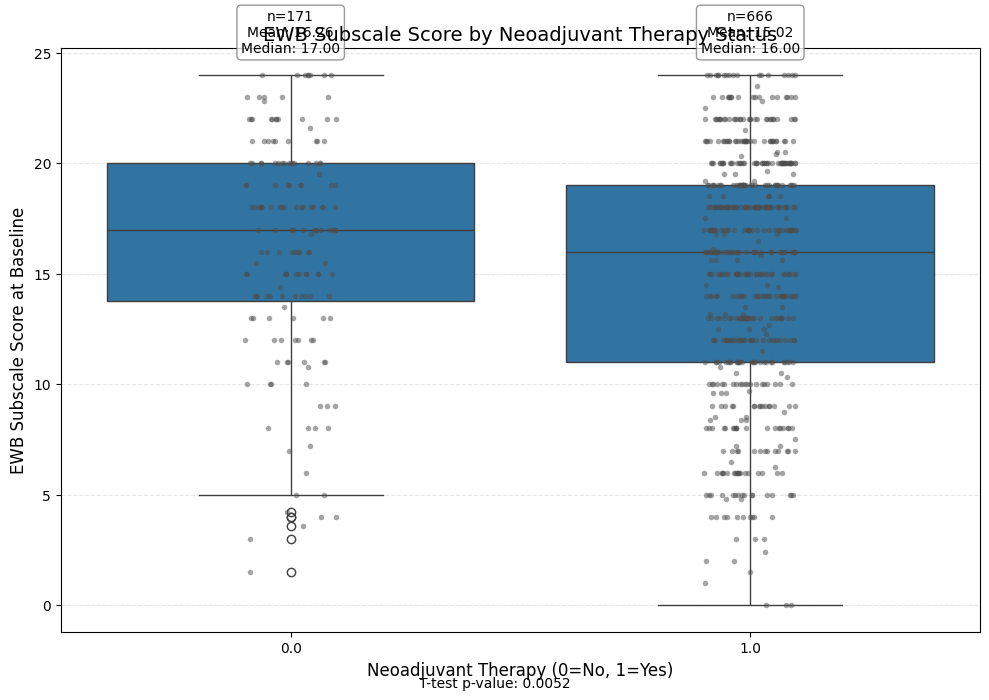

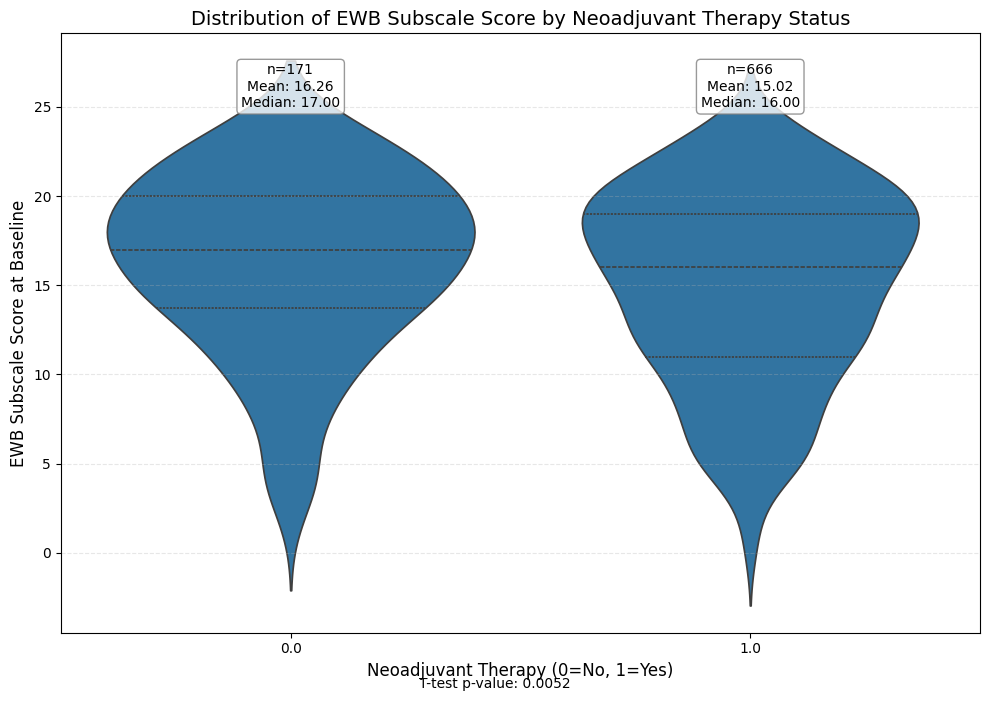

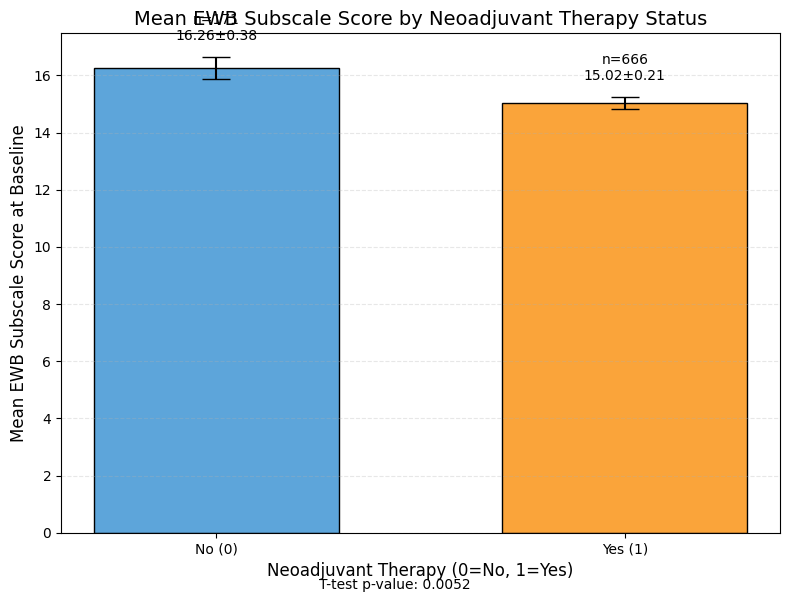

In [72]:

df = merged_df_removedNA_neo.copy()

# Since neotx___binary is binary (0 vs 1), we can use a box plot
plt.figure(figsize=(10, 7))

# Create box plot
sns.boxplot(x='neotx___binary', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='neotx___binary', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.5, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Neoadjuvant Therapy Status', fontsize=14)
plt.xlabel('Neoadjuvant Therapy (0=No, 1=Yes)', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display summary statistics
neotx_values = [0, 1]
for i, neotx_status in enumerate(neotx_values):
    subset = df[df['neotx___binary'] == neotx_status]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform t-test to compare the two groups
neotx_0 = df[df['neotx___binary'] == 0]['ewb_subscale_score_baseline'].dropna()
neotx_1 = df[df['neotx___binary'] == 1]['ewb_subscale_score_baseline'].dropna()
if len(neotx_0) > 0 and len(neotx_1) > 0:
    stat, p_value = stats.ttest_ind(neotx_0, neotx_1, equal_var=False)
    plt.figtext(0.5, 0.01, f'T-test p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()

# Create a violin plot to better visualize the distributions
plt.figure(figsize=(10, 7))
sns.violinplot(x='neotx___binary', y='ewb_subscale_score_baseline', data=df, inner='quartile')

plt.title('Distribution of EWB Subscale Score by Neoadjuvant Therapy Status', fontsize=14)
plt.xlabel('Neoadjuvant Therapy (0=No, 1=Yes)', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add the same statistics
for i, neotx_status in enumerate(neotx_values):
    subset = df[df['neotx___binary'] == neotx_status]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.figtext(0.5, 0.01, f'T-test p-value: {p_value:.4f}', ha='center', fontsize=10)
plt.tight_layout()

# Create a bar chart comparing the means with error bars
plt.figure(figsize=(8, 6))

# Calculate means and standard errors
means = df.groupby('neotx___binary')['ewb_subscale_score_baseline'].mean()
stderrs = df.groupby('neotx___binary')['ewb_subscale_score_baseline'].sem()
counts = df.groupby('neotx___binary').size()

# Create the bar chart
bars = plt.bar([0, 1], means, yerr=stderrs, capsize=10, color=['#5DA5DA', '#FAA43A'], 
        edgecolor='black', width=0.6)

# Add data labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + stderrs[i] + 0.5,
            f'n={counts[i]}\n{means[i]:.2f}±{stderrs[i]:.2f}',
            ha='center', va='bottom', fontsize=10)

plt.title('Mean EWB Subscale Score by Neoadjuvant Therapy Status', fontsize=14)
plt.xlabel('Neoadjuvant Therapy (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Mean EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.figtext(0.5, 0.01, f'T-test p-value: {p_value:.4f}', ha='center', fontsize=10)
plt.tight_layout()

plt.show()

# statistically significantly associated with 10) surgery type (procedure123456)

In [73]:
# Merge score_comparison with procedure123456 data
merged_df_procedure = score_comparison.merge(df_extracted[["id", "procedure123456"]], on="id", how="left")

# Remove rows where procedure123456 is missing
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()
merged_df_removedNA_procedure

,id,baseline_type,ewb_subscale_score_baseline,procedure123456
0,2,baseline_arm_1,14.0,1.0
7,3,baseline_arm_1,14.0,2.0
20,4,baseline_arm_1,23.0,1.0
27,7,baseline_arm_1,5.0,1.0
33,9,baseline_arm_1,20.0,1.0
...,...,...,...,...
5995,1721,baseline_arm_1,12.0,1.0
6006,1729,baseline_arm_1,18.0,1.0
6036,1743,baseline_arm_1,20.0,2.0
6054,1748,baseline_arm_1,9.0,1.0


In [77]:


def analyze_ewb_procedure_association(data_path=None, df=None):
    """
    Analyze the association between baseline EWB scores and procedure type
    
    Parameters:
    data_path (str): Path to CSV file containing the data (optional)
    df (DataFrame): Pandas DataFrame containing the data (optional)
    
    Returns:
    tuple: (DataFrame, Statistical Test Results)
    """
    df = data_path.copy()
    
    # Ensure proper data types
    df['ewb_subscale_score_baseline'] = pd.to_numeric(df['ewb_subscale_score_baseline'], errors='coerce')
    df['procedure123456'] = pd.to_numeric(df['procedure123456'], errors='coerce')
    
    # Remove rows with missing values in key columns
    df_clean = df.dropna(subset=['ewb_subscale_score_baseline', 'procedure123456'])
    
    print(f"Analysis based on {len(df_clean)} complete cases")
    
    # Map procedure codes to more descriptive labels (modify as needed)
    procedure_labels = {
        1.0: "Procedure Type 1",
        2.0: "Procedure Type 2",
        3.0: "Procedure Type 3",
        4.0: "Procedure Type 4",
        5.0: "Procedure Type 5",
        6.0: "Procedure Type 6",
        8.0: "Procedure Type 8"
    }
    
    # Add procedure labels
    df_clean['procedure_label'] = df_clean['procedure123456'].map(procedure_labels)
    
    # Check unique values in procedure123456
    procedure_categories = sorted(df_clean['procedure123456'].unique())
    print(f"\nFound {len(procedure_categories)} unique procedure types: {procedure_categories}")
    
    # Basic descriptive statistics by procedure type
    print("\n--- Descriptive Statistics by Procedure Type ---")
    stats_by_procedure = df_clean.groupby('procedure123456')['ewb_subscale_score_baseline'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    print(stats_by_procedure)
    
    # ANOVA to test for differences among procedure types
    if len(procedure_categories) >= 2:
        print("\n--- One-way ANOVA ---")
        model = ols('ewb_subscale_score_baseline ~ C(procedure123456)', data=df_clean).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(anova_table)
        
        f_stat = anova_table['F'][0]
        p_value = anova_table['PR(>F)'][0]
        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value: {p_value:.4f}")
        print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
        
        # If ANOVA is significant, perform post-hoc tests
        if p_value < 0.05:
            print("\n--- Post-hoc Tests (Tukey HSD) ---")
            try:
                from statsmodels.stats.multicomp import pairwise_tukeyhsd
                
                # Prepare data for Tukey's test
                endog = df_clean['ewb_subscale_score_baseline']
                groups = df_clean['procedure123456']
                
                # Perform Tukey's test
                tukey = pairwise_tukeyhsd(endog=endog, groups=groups, alpha=0.05)
                print(tukey)
                
                # Calculate effect size (Eta-squared)
                ss_between = anova_table['sum_sq'][0]
                ss_total = ss_between + anova_table['sum_sq'][1]
                eta_squared = ss_between / ss_total
                
                print(f"\nEffect size (Eta-squared): {eta_squared:.4f}")
                
                if eta_squared < 0.01:
                    effect_size_interp = "negligible"
                elif eta_squared < 0.06:
                    effect_size_interp = "small"
                elif eta_squared < 0.14:
                    effect_size_interp = "medium"
                else:
                    effect_size_interp = "large"
                
                print(f"Effect size interpretation: {effect_size_interp}")
            except Exception as e:
                print(f"Could not perform post-hoc tests: {e}")
                print("This may occur if some procedure groups have insufficient data")
    
    # Kruskal-Wallis H-test (non-parametric alternative to ANOVA)
    if len(procedure_categories) >= 2:
        print("\n--- Kruskal-Wallis H Test ---")
        
        # Prepare groups for test
        groups = []
        for proc in procedure_categories:
            group = df_clean[df_clean['procedure123456'] == proc]['ewb_subscale_score_baseline']
            if len(group) > 0:
                groups.append(group)
        
        if len(groups) >= 2:  # Need at least two groups
            try:
                h_stat, p_value_kw = stats.kruskal(*groups)
                
                print(f"H-statistic: {h_stat:.4f}")
                print(f"p-value: {p_value_kw:.4f}")
                print(f"Statistically significant: {'Yes' if p_value_kw < 0.05 else 'No'}")
                
                # If Kruskal-Wallis is significant, can do pairwise Mann-Whitney U tests
                if p_value_kw < 0.05:
                    print("\n--- Post-hoc Pairwise Comparisons (Mann-Whitney U) ---")
                    print("Note: No correction for multiple comparisons is applied")
                    
                    for i, cat1 in enumerate(procedure_categories):
                        for cat2 in procedure_categories[i+1:]:
                            group1 = df_clean[df_clean['procedure123456'] == cat1]['ewb_subscale_score_baseline']
                            group2 = df_clean[df_clean['procedure123456'] == cat2]['ewb_subscale_score_baseline']
                            
                            if len(group1) > 0 and len(group2) > 0:
                                u_stat, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided')
                                print(f"Procedure {cat1} vs {cat2}: U={u_stat:.1f}, p={p_mw:.4f}, {'Significant' if p_mw < 0.05 else 'Not significant'}")
            except Exception as e:
                print(f"Could not perform Kruskal-Wallis test: {e}")
                print("This may occur if procedure groups have insufficient data")
        else:
            print("Cannot perform Kruskal-Wallis test: Need at least 2 groups with data")
    
    # If there are only 2 procedure types, perform t-test
    if len(procedure_categories) == 2:
        print("\n--- Independent Samples T-Test ---")
        
        group1 = df_clean[df_clean['procedure123456'] == procedure_categories[0]]['ewb_subscale_score_baseline']
        group2 = df_clean[df_clean['procedure123456'] == procedure_categories[1]]['ewb_subscale_score_baseline']
        
        if len(group1) > 1 and len(group2) > 1:
            t_stat, p_value_t = stats.ttest_ind(
                group1,
                group2,
                equal_var=False  # Using Welch's t-test which doesn't assume equal variances
            )
            
            print(f"Comparing Procedure {procedure_categories[0]} vs {procedure_categories[1]}")
            print(f"t-statistic: {t_stat:.4f}")
            print(f"p-value: {p_value_t:.4f}")
            print(f"Statistically significant: {'Yes' if p_value_t < 0.05 else 'No'}")
            
            # Calculate effect size (Cohen's d)
            group1_mean = group1.mean()
            group2_mean = group2.mean()
            group1_std = group1.std()
            group2_std = group2.std()
            
            # Pooled standard deviation
            n1, n2 = len(group1), len(group2)
            pooled_std = np.sqrt(((n1 - 1) * group1_std**2 + (n2 - 1) * group2_std**2) / (n1 + n2 - 2))
            
            # Cohen's d
            cohens_d = abs(group1_mean - group2_mean) / pooled_std
            
            print(f"Effect size (Cohen's d): {cohens_d:.4f}")
            
            if cohens_d < 0.2:
                effect_size_interp = "negligible"
            elif cohens_d < 0.5:
                effect_size_interp = "small"
            elif cohens_d < 0.8:
                effect_size_interp = "medium"
            else:
                effect_size_interp = "large"
            
            print(f"Effect size interpretation: {effect_size_interp}")
    
    # SKIP problematic dummy variable regression
    print("\n--- Linear Regression with Categorical Procedure Types ---")
    print("Using statsmodels formula approach instead of manual dummy variables")
    
    # Use the formula interface which handles categorical variables correctly
    model_categorical = ols('ewb_subscale_score_baseline ~ C(procedure123456)', data=df_clean).fit()
    print(model_categorical.summary())
    
    # Interpretation
    print("\n--- Interpretation ---")
    
    if len(procedure_categories) >= 2:
        if p_value < 0.05 or (len(procedure_categories) == 2 and 'p_value_t' in locals() and p_value_t < 0.05):
            print(f"There is a statistically significant difference in EWB scores among different procedure types")
            
            # Find procedure with highest and lowest mean EWB scores
            mean_ewb_by_procedure = df_clean.groupby('procedure123456')['ewb_subscale_score_baseline'].mean()
            max_ewb_procedure = mean_ewb_by_procedure.idxmax()
            min_ewb_procedure = mean_ewb_by_procedure.idxmin()
            max_ewb_value = mean_ewb_by_procedure.max()
            min_ewb_value = mean_ewb_by_procedure.min()
            
            print(f"Procedure type {max_ewb_procedure} has the highest mean EWB score ({max_ewb_value:.2f})")
            print(f"Procedure type {min_ewb_procedure} has the lowest mean EWB score ({min_ewb_value:.2f})")
            print(f"The difference between highest and lowest is {max_ewb_value - min_ewb_value:.2f} points")
        else:
            print(f"There is NO statistically significant difference in EWB scores among different procedure types")
            print(f"This suggests that the type of procedure is not strongly associated with emotional well-being scores")
    
    # Additional clinical interpretation
    print("\n--- Clinical Relevance ---")
    print("Note: A difference of 2-3 points in the FACT-G EWB subscale is often considered")
    print("clinically meaningful. The statistical significance and the magnitude of the")
    print("differences should both be considered when interpreting these results.")
    
    return df_clean, (f_stat, p_value) if len(procedure_categories) >= 2 else None

# Example usage:
df, test_results = analyze_ewb_procedure_association(merged_df_removedNA_procedure)

Analysis based on 588 complete cases

Found 7 unique procedure types: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]

--- Descriptive Statistics by Procedure Type ---
                 count       mean       std   min  median   max
procedure123456                                                
1.0                339  15.327729  5.477248   0.0    16.0  24.0
2.0                117  15.803704  4.965206   2.0    16.0  24.0
3.0                 17  15.930392  3.598911   9.0    16.0  22.0
4.0                 75  15.376000  4.778583   0.0    16.0  24.0
5.0                 18  15.888889  5.279136   5.0    15.5  23.0
6.0                  5  17.900000  5.296225  11.0    21.0  23.0
8.0                 17  15.913725  3.961307   8.0    16.0  23.0

--- One-way ANOVA ---
                          sum_sq     df         F   PR(>F)
C(procedure123456)     59.584200    6.0  0.366707  0.90005
Residual            15733.926474  581.0       NaN      NaN
F-statistic: 0.3667
p-value: 0.9001
Statistically significant: No

-

/tmp/ipykernel_64923/85378195.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f_stat = anova_table['F'][0]
/tmp/ipykernel_64923/85378195.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]


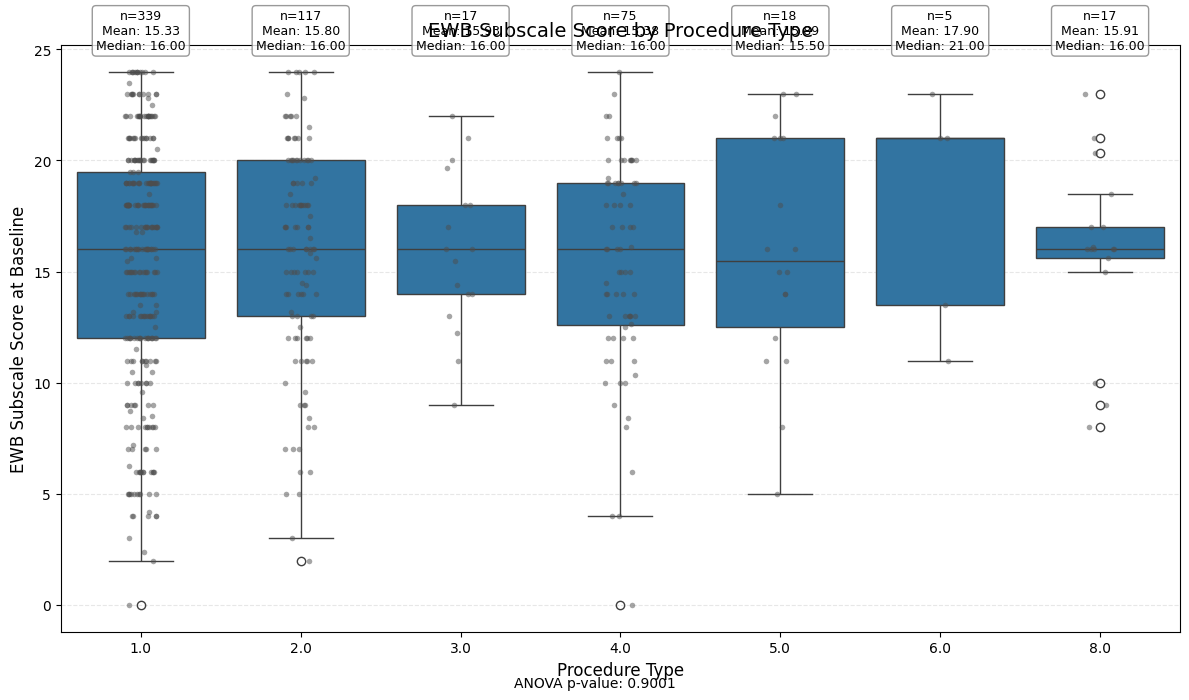

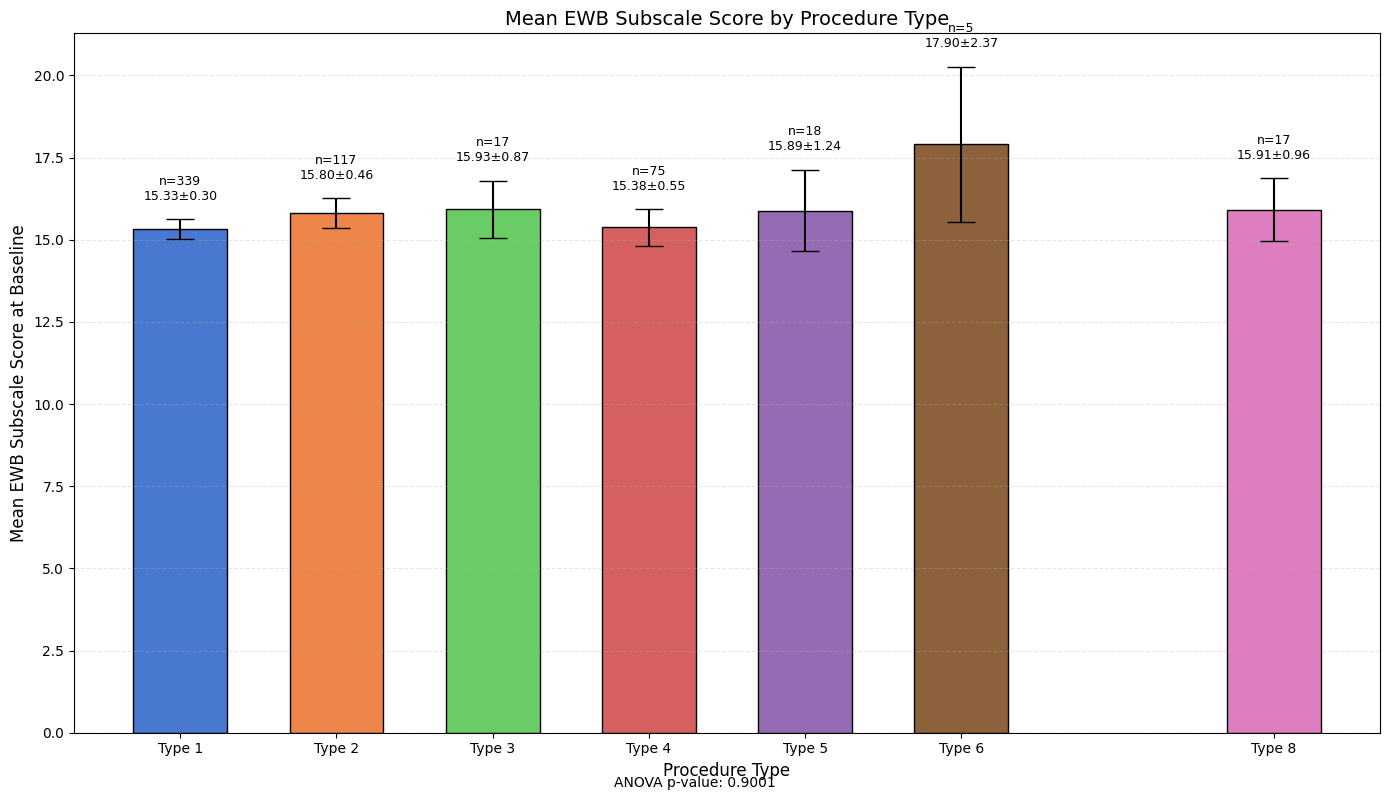

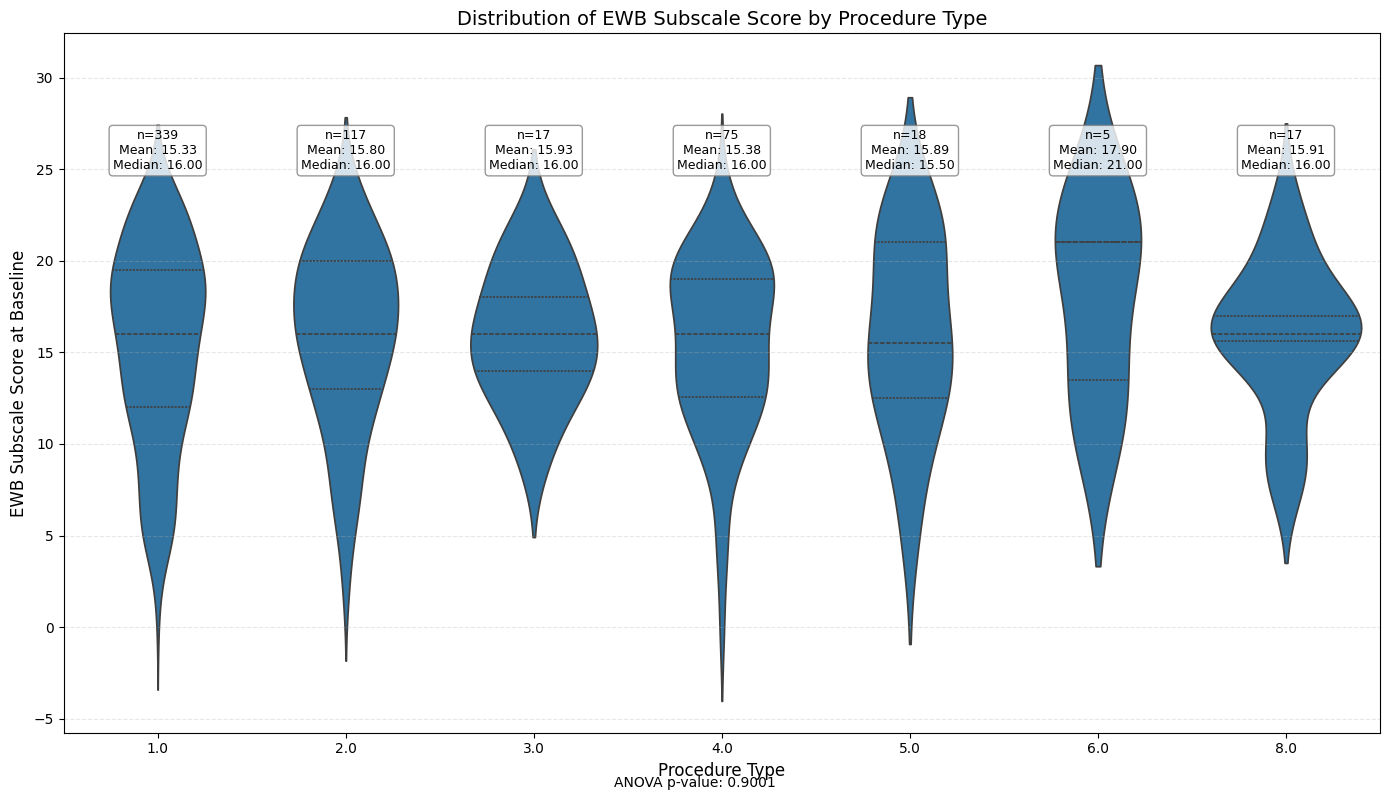

In [78]:

df = merged_df_removedNA_procedure.copy()

# From the data, it looks like procedure123456 has values like 1.0 and 2.0
# Let's create a boxplot to compare EWB scores across procedure types
plt.figure(figsize=(12, 7))

# Create box plot
sns.boxplot(x='procedure123456', y='ewb_subscale_score_baseline', data=df)

# Add individual data points with jitter for better visibility
sns.stripplot(x='procedure123456', y='ewb_subscale_score_baseline', data=df, 
              size=4, color='0.3', alpha=0.5, jitter=True)

# Improve the appearance
plt.title('EWB Subscale Score by Procedure Type', fontsize=14)
plt.xlabel('Procedure Type', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Calculate and display summary statistics for each procedure type
procedure_types = sorted(df['procedure123456'].unique())
for i, proc_type in enumerate(procedure_types):
    subset = df[df['procedure123456'] == proc_type]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Perform statistical test (ANOVA) if there are more than 2 groups
if len(procedure_types) > 2:
    groups = [df[df['procedure123456'] == p]['ewb_subscale_score_baseline'].dropna() for p in procedure_types]
    groups = [g for g in groups if len(g) > 0]  # Remove empty groups
    if len(groups) > 1:
        f_stat, p_value = stats.f_oneway(*groups)
        plt.figtext(0.5, 0.01, f'ANOVA p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()

# Create a grouped bar chart for a clearer comparison
plt.figure(figsize=(14, 8))

# Calculate means, standard errors, and counts for each procedure type
summary_data = df.groupby('procedure123456')['ewb_subscale_score_baseline'].agg(['mean', 'sem', 'count']).reset_index()

# Create the bar chart
bars = plt.bar(summary_data['procedure123456'], summary_data['mean'], 
               yerr=summary_data['sem'], capsize=10, 
               color=sns.color_palette('muted', len(summary_data)), 
               edgecolor='black', width=0.6)

# Add data labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + summary_data['sem'].iloc[i] + 0.5,
            f'n={summary_data["count"].iloc[i]}\n{summary_data["mean"].iloc[i]:.2f}±{summary_data["sem"].iloc[i]:.2f}',
            ha='center', va='bottom', fontsize=9, rotation=0)

plt.title('Mean EWB Subscale Score by Procedure Type', fontsize=14)
plt.xlabel('Procedure Type', fontsize=12)
plt.ylabel('Mean EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.xticks(procedure_types, [f'Type {int(p)}' for p in procedure_types])

if len(procedure_types) > 2:
    plt.figtext(0.5, 0.01, f'ANOVA p-value: {p_value:.4f}', ha='center', fontsize=10)

plt.tight_layout()

# Create a violin plot for better distribution visualization
plt.figure(figsize=(14, 8))
sns.violinplot(x='procedure123456', y='ewb_subscale_score_baseline', data=df, inner='quartile')

plt.title('Distribution of EWB Subscale Score by Procedure Type', fontsize=14)
plt.xlabel('Procedure Type', fontsize=12)
plt.ylabel('EWB Subscale Score at Baseline', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Add the same statistics
for i, proc_type in enumerate(procedure_types):
    subset = df[df['procedure123456'] == proc_type]['ewb_subscale_score_baseline']
    if not subset.empty:
        mean_val = subset.mean()
        median_val = subset.median()
        count = len(subset)
        plt.text(i, df['ewb_subscale_score_baseline'].max() + 1, 
                f'n={count}\nMean: {mean_val:.2f}\nMedian: {median_val:.2f}', 
                ha='center', fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

if len(procedure_types) > 2:
    plt.figtext(0.5, 0.01, f'ANOVA p-value: {p_value:.4f}', ha='center', fontsize=10)
    
plt.tight_layout()

plt.show()

# statistically significantly associated with 11) Multivariate 

#### when y = postop_comp

In [97]:
# Start with the first variable 
base_df = score_comparison.merge(df_extracted[["id", "age_diagnosis"]], on="id", how="left")
base_df = base_df.drop_duplicates()
base_df = base_df.dropna(subset=["age_diagnosis"])


# Start with the first variable 
gender_df = base_df.merge(df_extracted[["id", "gender"]], on="id", how="left")
gender_df = gender_df.drop_duplicates()
gender_df = gender_df.dropna(subset=["gender"])

# Start with tumor_df
tumor_df = gender_df.merge(df_extracted[["id", "overall_primary_tumour"]], on="id", how="left")
# Map tumor values
tumor_df["overall_primary_tumour"] = tumor_df["overall_primary_tumour"].map({
    "99": None, "0": 0, "00": 0, "1": 1, "1a": 1, "1b": 1, 
    "2": 2, "3": 3, "4": 4, "4a": 4, "4b": 4, "5": None
})
tumor_df = tumor_df.drop_duplicates()
tumor_df = tumor_df.dropna(subset=["overall_primary_tumour"])

# Start with ln_df
ln_df = tumor_df.merge(df_extracted[["id", "overall_regional_ln"]], on="id", how="left")
# Map ln values
ln_df["overall_regional_ln"] = ln_df["overall_regional_ln"].map({
    "99": None, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "pos": 1
})
ln_df = ln_df.drop_duplicates()
ln_df = ln_df.dropna(subset=["overall_regional_ln"])


# Start with metastasis_df
metastasis_df = ln_df.merge(df_extracted[["id", "overall_distant_metastasis"]], on="id", how="left")
# Map metastasis values
metastasis_df["overall_distant_metastasis"] = metastasis_df["overall_distant_metastasis"].map({0: 0, 1: 1, 2: None})
metastasis_df = metastasis_df.drop_duplicates()
metastasis_df = metastasis_df.dropna(subset=["overall_distant_metastasis"])


# Start with neonotx_df
neonotx_df = metastasis_df.merge(df_with_binary[["id", "neotx___binary"]], on="id", how="left")
neonotx_df = neonotx_df.drop_duplicates()
neonotx_df = neonotx_df.dropna(subset=["neotx___binary"])



# Merge score_comparison with postop_comp data (assuming both have "id" as a common key)
postop_df = neonotx_df.merge(df_extracted[["id", "DischargeDate", "postop_comp", "readmission_30d"]], on="id", how="left")
postop_df = postop_df.dropna(subset=["postop_comp"])
postop_df = postop_df.drop_duplicates()
postop_df = postop_df.sort_values(
    by=["id", "DischargeDate", "postop_comp"], 
    ascending=[True, True, False]
)
# Keep first occurrence of each ID (which will be the earliest DischargeDate due to sorting)
postop_df = postop_df.drop_duplicates(subset=["id"], keep="first")
# Remove rows where readmission_30d is 1
postop_df = postop_df[postop_df["readmission_30d"] != 1]
# Drop readmission_30d column
postop_df = postop_df.drop(columns=["readmission_30d"])
postop_df = postop_df.drop(columns=["DischargeDate"])



# Merge neoother_df with readmission_30d data
readmits_df = postop_df.merge(df_extracted[["id", "readmission_30d"]], on="id", how="left")
readmits_df = readmits_df.dropna(subset=["readmission_30d"])
# Identify ids that have both 0 and 1 for readmission_30d
id_counts = readmits_df.groupby("id")["readmission_30d"].nunique()
ids_with_both = id_counts[id_counts > 1].index
# Remove rows where readmission_30d is 0 for those ids
readmits_df = readmits_df[
    ~(readmits_df["id"].isin(ids_with_both) & (readmits_df["readmission_30d"] == 0))
]
readmits_df = readmits_df.drop_duplicates().copy()


# Merge neoother_df with readmission_30d data
los_df = readmits_df.merge(df_extracted[["id", "los"]], on="id", how="left")
los_df = los_df.drop_duplicates()
los_df = los_df.dropna(subset=["los"])

# Merge score_comparison with procedure123456 data
merged_df_procedure = los_df.merge(df_extracted[["id", "procedure123456"]], on="id", how="left")

# Remove rows where procedure123456 is missing
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()
merged_df_removedNA_procedure

merged_df_removedNA_procedure



,id,baseline_type,ewb_subscale_score_baseline,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___binary,postop_comp,readmission_30d,los,procedure123456
3,20,baseline_arm_1,16.0,59.771248,1.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,2.0
9,26,baseline_arm_1,22.0,57.038817,2.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0
17,26,baseline_arm_1,22.0,57.038817,2.0,3.0,1.0,0.0,0.0,0.0,0.0,9.0,4.0
29,32,baseline_arm_1,6.0,29.722718,1.0,3.0,0.0,0.0,1.0,1.0,0.0,15.0,1.0
36,55,baseline_arm_1,8.0,64.617343,1.0,3.0,1.0,0.0,1.0,0.0,0.0,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3201,1679,baseline_arm_1,23.0,76.645083,1.0,3.0,1.0,0.0,1.0,1.0,0.0,10.0,1.0
3210,1683,baseline_arm_1,16.0,68.433872,1.0,3.0,0.0,0.0,1.0,1.0,0.0,7.0,4.0
3216,1687,baseline_arm_1,10.0,69.099183,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3222,1687,baseline_arm_1,10.0,69.099183,1.0,1.0,0.0,0.0,0.0,0.0,1.0,20.0,1.0


In [99]:

X = merged_df_removedNA_procedure[['ewb_subscale_score_baseline', "readmission_30d", "los", 'age_diagnosis', 'gender', 
                'overall_primary_tumour', 'overall_regional_ln', 
                'overall_distant_metastasis', 'neotx___binary', "procedure123456"]]
y = merged_df_removedNA_procedure['postop_comp']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display the summary of the regression
print("\nLogistic Regression Results:")
print(result.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios and Confidence Intervals:")
params = result.params
conf = result.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf['Odds Ratio'] = np.exp(conf['Odds Ratio'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf)

Optimization terminated successfully.
         Current function value: 0.634723
         Iterations 6

Logistic Regression Results:
                           Logit Regression Results                           
Dep. Variable:            postop_comp   No. Observations:                  394
Model:                          Logit   Df Residuals:                      383
Method:                           MLE   Df Model:                           10
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.07671
Time:                        15:56:06   Log-Likelihood:                -250.08
converged:                       True   LL-Null:                       -270.86
Covariance Type:            nonrobust   LLR p-value:                 9.005e-06
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           1.7402      

#### when y = Readmission_30d

In [100]:
# Start with the first variable 
base_df = score_comparison.merge(df_extracted[["id", "age_diagnosis"]], on="id", how="left")
base_df = base_df.drop_duplicates()
base_df = base_df.dropna(subset=["age_diagnosis"])


# Start with the first variable 
gender_df = base_df.merge(df_extracted[["id", "gender"]], on="id", how="left")
gender_df = gender_df.drop_duplicates()
gender_df = gender_df.dropna(subset=["gender"])

# Start with tumor_df
tumor_df = gender_df.merge(df_extracted[["id", "overall_primary_tumour"]], on="id", how="left")
# Map tumor values
tumor_df["overall_primary_tumour"] = tumor_df["overall_primary_tumour"].map({
    "99": None, "0": 0, "00": 0, "1": 1, "1a": 1, "1b": 1, 
    "2": 2, "3": 3, "4": 4, "4a": 4, "4b": 4, "5": None
})
tumor_df = tumor_df.drop_duplicates()
tumor_df = tumor_df.dropna(subset=["overall_primary_tumour"])

# Start with ln_df
ln_df = tumor_df.merge(df_extracted[["id", "overall_regional_ln"]], on="id", how="left")
# Map ln values
ln_df["overall_regional_ln"] = ln_df["overall_regional_ln"].map({
    "99": None, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "pos": 1
})
ln_df = ln_df.drop_duplicates()
ln_df = ln_df.dropna(subset=["overall_regional_ln"])


# Start with metastasis_df
metastasis_df = ln_df.merge(df_extracted[["id", "overall_distant_metastasis"]], on="id", how="left")
# Map metastasis values
metastasis_df["overall_distant_metastasis"] = metastasis_df["overall_distant_metastasis"].map({0: 0, 1: 1, 2: None})
metastasis_df = metastasis_df.drop_duplicates()
metastasis_df = metastasis_df.dropna(subset=["overall_distant_metastasis"])


# Start with neonotx_df
neonotx_df = metastasis_df.merge(df_with_binary[["id", "neotx___binary"]], on="id", how="left")
neonotx_df = neonotx_df.drop_duplicates()
neonotx_df = neonotx_df.dropna(subset=["neotx___binary"])



# Merge score_comparison with postop_comp data (assuming both have "id" as a common key)
postop_df = neonotx_df.merge(df_extracted[["id", "DischargeDate", "postop_comp", "readmission_30d"]], on="id", how="left")
postop_df = postop_df.dropna(subset=["postop_comp"])
postop_df = postop_df.drop_duplicates()
postop_df = postop_df.sort_values(
    by=["id", "DischargeDate", "postop_comp"], 
    ascending=[True, True, False]
)
# Keep first occurrence of each ID (which will be the earliest DischargeDate due to sorting)
postop_df = postop_df.drop_duplicates(subset=["id"], keep="first")
# Remove rows where readmission_30d is 1
postop_df = postop_df[postop_df["readmission_30d"] != 1]
# Drop readmission_30d column
postop_df = postop_df.drop(columns=["readmission_30d"])
postop_df = postop_df.drop(columns=["DischargeDate"])



# Merge neoother_df with readmission_30d data
readmits_df = postop_df.merge(df_extracted[["id", "readmission_30d"]], on="id", how="left")
readmits_df = readmits_df.dropna(subset=["readmission_30d"])
# Identify ids that have both 0 and 1 for readmission_30d
id_counts = readmits_df.groupby("id")["readmission_30d"].nunique()
ids_with_both = id_counts[id_counts > 1].index
# Remove rows where readmission_30d is 0 for those ids
readmits_df = readmits_df[
    ~(readmits_df["id"].isin(ids_with_both) & (readmits_df["readmission_30d"] == 0))
]
readmits_df = readmits_df.drop_duplicates().copy()


# Merge neoother_df with readmission_30d data
los_df = readmits_df.merge(df_extracted[["id", "los"]], on="id", how="left")
los_df = los_df.drop_duplicates()
los_df = los_df.dropna(subset=["los"])

# Merge score_comparison with procedure123456 data
merged_df_procedure = los_df.merge(df_extracted[["id", "procedure123456"]], on="id", how="left")

# Remove rows where procedure123456 is missing
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()
merged_df_removedNA_procedure

merged_df_removedNA_procedure



,id,baseline_type,ewb_subscale_score_baseline,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___binary,postop_comp,readmission_30d,los,procedure123456
3,20,baseline_arm_1,16.0,59.771248,1.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,2.0
9,26,baseline_arm_1,22.0,57.038817,2.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0
17,26,baseline_arm_1,22.0,57.038817,2.0,3.0,1.0,0.0,0.0,0.0,0.0,9.0,4.0
29,32,baseline_arm_1,6.0,29.722718,1.0,3.0,0.0,0.0,1.0,1.0,0.0,15.0,1.0
36,55,baseline_arm_1,8.0,64.617343,1.0,3.0,1.0,0.0,1.0,0.0,0.0,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3201,1679,baseline_arm_1,23.0,76.645083,1.0,3.0,1.0,0.0,1.0,1.0,0.0,10.0,1.0
3210,1683,baseline_arm_1,16.0,68.433872,1.0,3.0,0.0,0.0,1.0,1.0,0.0,7.0,4.0
3216,1687,baseline_arm_1,10.0,69.099183,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3222,1687,baseline_arm_1,10.0,69.099183,1.0,1.0,0.0,0.0,0.0,0.0,1.0,20.0,1.0


In [101]:

X = merged_df_removedNA_procedure[['ewb_subscale_score_baseline', "postop_comp", "los", 'age_diagnosis', 'gender', 
                'overall_primary_tumour', 'overall_regional_ln', 
                'overall_distant_metastasis', 'neotx___binary', "procedure123456"]]
y = merged_df_removedNA_procedure['readmission_30d']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Display the summary of the regression
print("\nLogistic Regression Results:")
print(result.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios and Confidence Intervals:")
params = result.params
conf = result.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf['Odds Ratio'] = np.exp(conf['Odds Ratio'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf)

Optimization terminated successfully.
         Current function value: 0.318767
         Iterations 7

Logistic Regression Results:
                           Logit Regression Results                           
Dep. Variable:        readmission_30d   No. Observations:                  394
Model:                          Logit   Df Residuals:                      383
Method:                           MLE   Df Model:                           10
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.07525
Time:                        15:57:27   Log-Likelihood:                -125.59
converged:                       True   LL-Null:                       -135.81
Covariance Type:            nonrobust   LLR p-value:                   0.02535
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -2.8758      

#### when y = los

In [103]:
# Start with the first variable 
base_df = score_comparison.merge(df_extracted[["id", "age_diagnosis"]], on="id", how="left")
base_df = base_df.drop_duplicates()
base_df = base_df.dropna(subset=["age_diagnosis"])


# Start with the first variable 
gender_df = base_df.merge(df_extracted[["id", "gender"]], on="id", how="left")
gender_df = gender_df.drop_duplicates()
gender_df = gender_df.dropna(subset=["gender"])

# Start with tumor_df
tumor_df = gender_df.merge(df_extracted[["id", "overall_primary_tumour"]], on="id", how="left")
# Map tumor values
tumor_df["overall_primary_tumour"] = tumor_df["overall_primary_tumour"].map({
    "99": None, "0": 0, "00": 0, "1": 1, "1a": 1, "1b": 1, 
    "2": 2, "3": 3, "4": 4, "4a": 4, "4b": 4, "5": None
})
tumor_df = tumor_df.drop_duplicates()
tumor_df = tumor_df.dropna(subset=["overall_primary_tumour"])

# Start with ln_df
ln_df = tumor_df.merge(df_extracted[["id", "overall_regional_ln"]], on="id", how="left")
# Map ln values
ln_df["overall_regional_ln"] = ln_df["overall_regional_ln"].map({
    "99": None, "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "pos": 1
})
ln_df = ln_df.drop_duplicates()
ln_df = ln_df.dropna(subset=["overall_regional_ln"])


# Start with metastasis_df
metastasis_df = ln_df.merge(df_extracted[["id", "overall_distant_metastasis"]], on="id", how="left")
# Map metastasis values
metastasis_df["overall_distant_metastasis"] = metastasis_df["overall_distant_metastasis"].map({0: 0, 1: 1, 2: None})
metastasis_df = metastasis_df.drop_duplicates()
metastasis_df = metastasis_df.dropna(subset=["overall_distant_metastasis"])


# Start with neonotx_df
neonotx_df = metastasis_df.merge(df_with_binary[["id", "neotx___binary"]], on="id", how="left")
neonotx_df = neonotx_df.drop_duplicates()
neonotx_df = neonotx_df.dropna(subset=["neotx___binary"])



# Merge score_comparison with postop_comp data (assuming both have "id" as a common key)
postop_df = neonotx_df.merge(df_extracted[["id", "DischargeDate", "postop_comp", "readmission_30d"]], on="id", how="left")
postop_df = postop_df.dropna(subset=["postop_comp"])
postop_df = postop_df.drop_duplicates()
postop_df = postop_df.sort_values(
    by=["id", "DischargeDate", "postop_comp"], 
    ascending=[True, True, False]
)
# Keep first occurrence of each ID (which will be the earliest DischargeDate due to sorting)
postop_df = postop_df.drop_duplicates(subset=["id"], keep="first")
# Remove rows where readmission_30d is 1
postop_df = postop_df[postop_df["readmission_30d"] != 1]
# Drop readmission_30d column
postop_df = postop_df.drop(columns=["readmission_30d"])
postop_df = postop_df.drop(columns=["DischargeDate"])



# Merge neoother_df with readmission_30d data
readmits_df = postop_df.merge(df_extracted[["id", "readmission_30d"]], on="id", how="left")
readmits_df = readmits_df.dropna(subset=["readmission_30d"])
# Identify ids that have both 0 and 1 for readmission_30d
id_counts = readmits_df.groupby("id")["readmission_30d"].nunique()
ids_with_both = id_counts[id_counts > 1].index
# Remove rows where readmission_30d is 0 for those ids
readmits_df = readmits_df[
    ~(readmits_df["id"].isin(ids_with_both) & (readmits_df["readmission_30d"] == 0))
]
readmits_df = readmits_df.drop_duplicates().copy()


# Merge neoother_df with readmission_30d data
los_df = readmits_df.merge(df_extracted[["id", "los"]], on="id", how="left")
los_df = los_df.drop_duplicates()
los_df = los_df.dropna(subset=["los"])

# Merge score_comparison with procedure123456 data
merged_df_procedure = los_df.merge(df_extracted[["id", "procedure123456"]], on="id", how="left")

# Remove rows where procedure123456 is missing
merged_df_removedNA_procedure = merged_df_procedure.dropna(subset=["procedure123456"])
merged_df_expanded_procedure = merged_df_removedNA_procedure.drop_duplicates()
merged_df_removedNA_procedure = merged_df_expanded_procedure.copy()
merged_df_removedNA_procedure

merged_df_removedNA_procedure



,id,baseline_type,ewb_subscale_score_baseline,age_diagnosis,gender,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___binary,postop_comp,readmission_30d,los,procedure123456
3,20,baseline_arm_1,16.0,59.771248,1.0,0.0,0.0,0.0,0.0,1.0,0.0,10.0,2.0
9,26,baseline_arm_1,22.0,57.038817,2.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0
17,26,baseline_arm_1,22.0,57.038817,2.0,3.0,1.0,0.0,0.0,0.0,0.0,9.0,4.0
29,32,baseline_arm_1,6.0,29.722718,1.0,3.0,0.0,0.0,1.0,1.0,0.0,15.0,1.0
36,55,baseline_arm_1,8.0,64.617343,1.0,3.0,1.0,0.0,1.0,0.0,0.0,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3201,1679,baseline_arm_1,23.0,76.645083,1.0,3.0,1.0,0.0,1.0,1.0,0.0,10.0,1.0
3210,1683,baseline_arm_1,16.0,68.433872,1.0,3.0,0.0,0.0,1.0,1.0,0.0,7.0,4.0
3216,1687,baseline_arm_1,10.0,69.099183,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
3222,1687,baseline_arm_1,10.0,69.099183,1.0,1.0,0.0,0.0,0.0,0.0,1.0,20.0,1.0


In [105]:

X = merged_df_removedNA_procedure[['ewb_subscale_score_baseline', "postop_comp", "readmission_30d", 'age_diagnosis', 'gender', 
                'overall_primary_tumour', 'overall_regional_ln', 
                'overall_distant_metastasis', 'neotx___binary', "procedure123456"]]
y = merged_df_removedNA_procedure['los']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
ols_model = sm.OLS(y, X)
result = ols_model.fit()

# Display the summary of the regression
print("\nLogistic Regression Results:")
print(result.summary())

# Calculate odds ratios and confidence intervals
print("\nOdds Ratios and Confidence Intervals:")
params = result.params
conf = result.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf['Odds Ratio'] = np.exp(conf['Odds Ratio'])
conf['2.5%'] = np.exp(conf['2.5%'])
conf['97.5%'] = np.exp(conf['97.5%'])
print(conf)


Logistic Regression Results:
                            OLS Regression Results                            
Dep. Variable:                    los   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     4.227
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           1.38e-05
Time:                        16:00:06   Log-Likelihood:                -1578.8
No. Observations:                 394   AIC:                             3180.
Df Residuals:                     383   BIC:                             3223.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------